# Comprehensive Data Cleaning with Pandas
## Prodigy Training Hub — Complete Teaching Guide

---

### What This Notebook Covers

| Module | Topic |
|---|---|
| **1** | Introduction to Data Cleaning — Why it matters |
| **2** | Detecting and Handling **Empty Cells** |
| **3** | Fixing **Wrong Format** — dates, phones, emails, numbers |
| **4** | Correcting **Wrong Data** — outliers, impossible values, typos |
| **5** | Removing **Duplicates** |
| **6** | End-to-End Cleaning Pipeline |

---

### The Dataset — `nigeria_cleaning_dataset.csv`

A Nigerian e-commerce sales dataset with **630 rows and 20 columns**, deliberately built with every type of data quality issue:

| Dirt Injected | Column(s) | Count |
|---|---|---|
| Empty cells (NaN) | customer_name, email, phone, state, age, rating, delivery_days, total_amount | 40–179 per column |
| Wrong format — dates | order_date | 25 rows as 'N/A', 15 as DD/MM/YYYY, 10 as 'Month DD, YYYY' |
| Wrong format — phones | customer_phone | 30 too-short, 20 wrong prefix |
| Wrong format — emails | customer_email | 20 no '@', 15 incomplete |
| Wrong data — outliers | customer_age (999), rating (-99), delivery_days (999), total_amount (0 or -999) | 6–10 each |
| Wrong data — invalid state | state | 12 typos, 8 invalid codes |
| **Duplicate rows** | All columns | 30 exact duplicate rows |

---

> **Rule:** Place `nigeria_cleaning_dataset.csv` and `nigeria_cleaning_dataset.xlsx` in the **same folder** as this notebook before running.

---

---
# SECTION 0: Setup and Loading

---

In [1]:
# ─────────────────────────────────────────────────────────────────
# CELL 0.1 — Import Libraries
# ─────────────────────────────────────────────────────────────────
import pandas as pd            # data analysis
import numpy as np             # numerical operations
import matplotlib.pyplot as plt # plotting
import re                      # regular expressions (for email/phone validation)
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

pd.set_option('display.max_columns', 22)
pd.set_option('display.max_rows', 40)
pd.set_option('display.width', 130)
pd.set_option('display.float_format', '{:,.2f}'.format)

print("Libraries loaded. Pandas:", pd.__version__)

Libraries loaded. Pandas: 2.3.1


In [2]:
# ─────────────────────────────────────────────────────────────────
# CELL 0.2 — Load the Raw Dataset
# ─────────────────────────────────────────────────────────────────

# Load the CSV — do NOT parse dates yet; we want to see them dirty first
df_raw = pd.read_csv('nigeria_cleaning_dataset.csv')

print(f"Raw dataset: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
print()
print("=== First 5 rows ===")
print(df_raw.head())

Raw dataset: 630 rows × 20 columns

=== First 5 rows ===
     order_id  order_date customer_name         customer_email   customer_phone   state platform   category  \
0  ORD-100000  2023-01-01   Customer_15  customer0@example.com              NaN  Rivers    Konga     Sports   
1  ORD-100001  2023-01-02   Customer_28  customer1@example.com 8,076,317,456.00     Imo     Jiji      Books   
2  ORD-100002  03/01/2023    Customer_4  customer2@example.com 8,073,801,590.00  Kaduna     Jiji  Furniture   
3  ORD-100003  2023-01-04   Customer_36  customer3@example.com 8,094,850,555.00     Imo    Jumia     Sports   
4  ORD-100004  2023-01-05   Customer_65  customer4@example.com 8,041,394,931.00   Abuja     Jiji  Groceries   

              product_name  unit_price  quantity  discount_pct  total_amount   payment_method  customer_age customer_gender  \
0        Yoga Mat Non-Slip   91,292.33         4            15    310,393.92              POS         64.00          Female   
1         ACCA F3 Text

In [3]:
# ─────────────────────────────────────────────────────────────────
# CELL 0.3 — Full Data Audit (run this on EVERY new dataset)
# ─────────────────────────────────────────────────────────────────

print("=" * 60)
print("FULL DATA AUDIT")
print("=" * 60)
print()

# 1. Shape
print(f"Rows    : {df_raw.shape[0]}")
print(f"Columns : {df_raw.shape[1]}")
print()

# 2. Data types
print("=== Data Types ===")
print(df_raw.dtypes)
print()

# 3. Missing values
print("=== Missing Values ===")
miss = df_raw.isnull().sum()
miss_pct = (miss / len(df_raw) * 100).round(1)
audit = pd.DataFrame({'Count': miss, 'Pct %': miss_pct})
print(audit[audit['Count'] > 0])
print()

# 4. Duplicates
print(f"=== Duplicate Rows : {df_raw.duplicated().sum()} ===")
print()

# 5. Statistical summary (spot numerical outliers)
print("=== Numeric Summary (spot impossible min/max) ===")
print(df_raw.describe())

FULL DATA AUDIT

Rows    : 630
Columns : 20

=== Data Types ===
order_id             object
order_date           object
customer_name        object
customer_email       object
customer_phone      float64
state                object
platform             object
category             object
product_name         object
unit_price          float64
quantity              int64
discount_pct          int64
total_amount        float64
payment_method       object
customer_age        float64
customer_gender      object
customer_segment     object
rating              float64
delivery_days       float64
returned               bool
dtype: object

=== Missing Values ===
                Count  Pct %
order_date         25   4.00
customer_name      31   4.90
customer_email     22   3.50
customer_phone     15   2.40
state              10   1.60
total_amount       13   2.10
customer_age       41   6.50
rating             36   5.70
delivery_days      11   1.70

=== Duplicate Rows : 30 ===

=== Numeric Summar

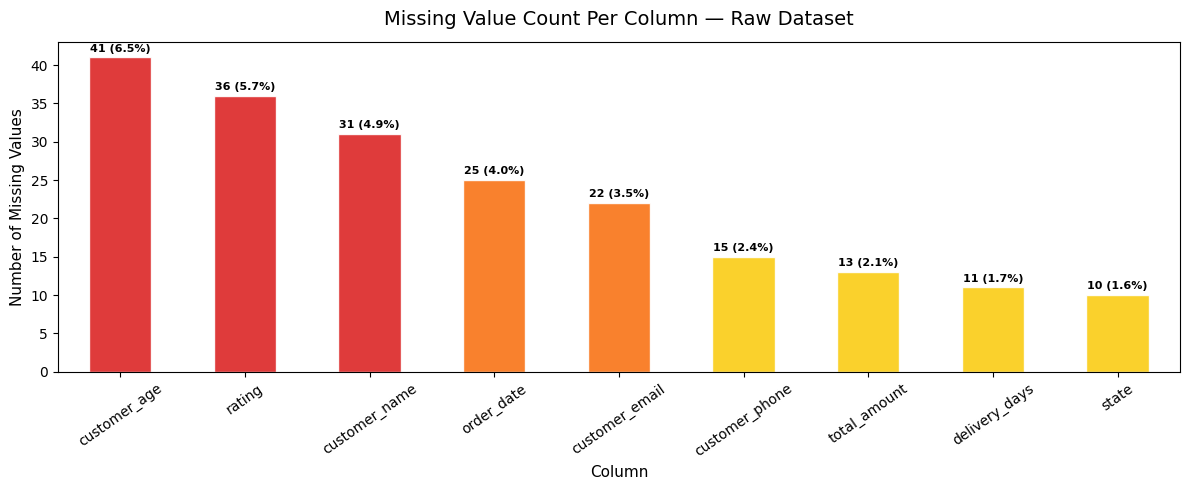

Chart saved.


In [4]:
# ─────────────────────────────────────────────────────────────────
# CELL 0.4 — Visualise Missing Values
# ─────────────────────────────────────────────────────────────────

miss_data = df_raw.isnull().sum()
miss_data = miss_data[miss_data > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
colors_bar = ['#dc2626' if v > 30 else '#f97316' if v > 15 else '#facc15'
              for v in miss_data.values]
miss_data.plot(kind='bar', ax=ax, color=colors_bar, edgecolor='white', alpha=0.9)

ax.set_title('Missing Value Count Per Column — Raw Dataset', fontsize=14, pad=12)
ax.set_xlabel('Column', fontsize=11)
ax.set_ylabel('Number of Missing Values', fontsize=11)
ax.tick_params(axis='x', rotation=35)

for bar in ax.patches:
    h = bar.get_height()
    pct = h / len(df_raw) * 100
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
            f'{int(h)} ({pct:.1f}%)', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('missing_values_audit.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

---
# SECTION 1: Introduction to Data Cleaning

---

## What Is Data Cleaning?

**Data cleaning** (also called data cleansing or data wrangling) is the process of detecting and fixing problems in a dataset so that it is accurate, complete, consistent, and ready for analysis.

> **"Garbage in, garbage out."**  
> No matter how advanced your analysis, if the data going in is dirty, the results coming out will be wrong.

---

## The Four Types of Data Problems We Fix

| Problem Type | Description | Example |
|---|---|---|
| **Empty Cells** | Missing values — no data recorded | `NaN`, blank cell, `NULL` |
| **Wrong Format** | Data present but in the wrong structure | Date as `'15/01/2024'` when expected `'2024-01-15'` |
| **Wrong Data** | Data present and formatted, but logically impossible | Age = `999`, Rating = `-99` |
| **Duplicates** | The same row appears more than once | Same order recorded twice |

---

## The Professional Cleaning Workflow

```
1. LOAD        → read the raw data
2. AUDIT       → df.info(), isnull().sum(), describe(), duplicated().sum()
3. CLEAN       → fix each problem type in order
4. VALIDATE    → confirm no issues remain
5. EXPORT      → save the clean data
```

---

## Why This Order Matters

- **Remove duplicates first** — otherwise you do double-work cleaning rows you'll delete later  
- **Fix types before filling missing values** — you can't compute median of a text column  
- **Fix outliers before computing fill values** — an outlier of 999 will inflate your mean  
- **Fix formats before analysis** — dates stored as text can't be sorted or compared correctly

In [5]:
# ─────────────────────────────────────────────────────────────────
# CELL 1.1 — The Cleaning Checklist (run before starting)
# ─────────────────────────────────────────────────────────────────

# A one-cell comprehensive dirt report you can run on ANY dataset
def cleaning_report(dataframe, name="Dataset"):
    print("=" * 65)
    print(f"CLEANING REPORT — {name}")
    print("=" * 65)
    print(f"  Shape        : {dataframe.shape[0]} rows × {dataframe.shape[1]} columns")
    print(f"  Duplicates   : {dataframe.duplicated().sum()} duplicate rows")
    print(f"  Total cells  : {dataframe.size}")
    total_null = dataframe.isnull().sum().sum()
    print(f"  Missing cells: {total_null} ({total_null/dataframe.size*100:.1f}% of all cells)")
    print()
    miss = dataframe.isnull().sum()
    miss = miss[miss > 0]
    if len(miss):
        print("  Columns with missing values:")
        for col, cnt in miss.items():
            print(f"    {col:<22} {cnt:>4} missing  ({cnt/len(dataframe)*100:.1f}%)")
    print("=" * 65)

cleaning_report(df_raw, "nigeria_cleaning_dataset.csv")

CLEANING REPORT — nigeria_cleaning_dataset.csv
  Shape        : 630 rows × 20 columns
  Duplicates   : 30 duplicate rows
  Total cells  : 12600
  Missing cells: 204 (1.6% of all cells)

  Columns with missing values:
    order_date               25 missing  (4.0%)
    customer_name            31 missing  (4.9%)
    customer_email           22 missing  (3.5%)
    customer_phone           15 missing  (2.4%)
    state                    10 missing  (1.6%)
    total_amount             13 missing  (2.1%)
    customer_age             41 missing  (6.5%)
    rating                   36 missing  (5.7%)
    delivery_days            11 missing  (1.7%)


---
# SECTION 2: Cleaning Empty Cells

---

## What Are Empty Cells?

An **empty cell** is a cell with no value. In Pandas, empty cells are represented as **`NaN`** (Not a Number) — a special floating-point value that means "no data here."

Empty cells come from:
- The person entering data left the field blank
- A system exported `NULL` or `N/A` from a database
- A formula in Excel returned an error
- Data was never collected for that row

---

## Detecting Empty Cells

| Command | What it shows |
|---|---|
| `df.isnull()` | DataFrame of True/False — True = missing |
| `df.isnull().sum()` | Count of NaN per column |
| `df.isnull().sum().sum()` | Total NaN cells in the entire DataFrame |
| `df.notnull().sum()` | Count of NON-missing values per column |
| `df[df['col'].isnull()]` | Filter: show only rows where a column is NaN |

---

## Strategies for Handling Empty Cells

| Strategy | When to Use | Code |
|---|---|---|
| **Drop the row** | NaN is in a critical column; row is useless without it | `df.dropna(subset=['col'])` |
| **Drop the column** | >50% of the column is missing | `df.drop(columns=['col'])` |
| **Fill with constant** | You know the right value (e.g., 0 for discount) | `df['col'].fillna(0)` |
| **Fill with mean** | Numeric column, no outliers | `df['col'].fillna(df['col'].mean())` |
| **Fill with median** | Numeric column WITH outliers | `df['col'].fillna(df['col'].median())` |
| **Fill with mode** | Categorical/text column | `df['col'].fillna(df['col'].mode()[0])` |
| **Forward fill** | Time-series data | `df['col'].ffill()` |
| **Backward fill** | Time-series data | `df['col'].bfill()` |

In [6]:
# ─────────────────────────────────────────────────────────────────
# CELL 2.1 — Detecting Empty Cells
# ─────────────────────────────────────────────────────────────────

# Work on a copy from this section onwards
df = df_raw.copy()

# isnull() returns True where a cell is NaN
print("=== isnull() — first 5 rows, selected columns ===")
print(df[['customer_name','customer_age','rating','total_amount']].isnull().head(8))
print()

# Count of missing values per column
print("=== Missing value count per column ===")
print(df.isnull().sum())
print()

# Total missing cells in the entire DataFrame
total_null = df.isnull().sum().sum()
print(f"Total missing cells: {total_null} out of {df.size} ({total_null/df.size*100:.1f}%)")

=== isnull() — first 5 rows, selected columns ===
   customer_name  customer_age  rating  total_amount
0          False         False    True         False
1          False          True    True         False
2          False         False   False         False
3          False         False   False         False
4          False         False   False         False
5          False         False   False         False
6           True         False   False         False
7          False         False   False         False

=== Missing value count per column ===
order_id             0
order_date          25
customer_name       31
customer_email      22
customer_phone      15
state               10
platform             0
category             0
product_name         0
unit_price           0
quantity             0
discount_pct         0
total_amount        13
payment_method       0
customer_age        41
customer_gender      0
customer_segment     0
rating              36
delivery_days      

In [7]:
# ─────────────────────────────────────────────────────────────────
# CELL 2.2 — Viewing Rows with Missing Values
# ─────────────────────────────────────────────────────────────────

# Filter: show only rows where customer_age is NaN
rows_missing_age = df[df['customer_age'].isnull()]
print(f"Rows with missing customer_age: {len(rows_missing_age)}")
print(rows_missing_age[['order_id','customer_name','customer_age','state']].head(8))
print()

# Rows missing ANY value across the entire DataFrame
rows_any_null = df[df.isnull().any(axis=1)]
# axis=1 means: check across columns (row-wise)
print(f"Rows with AT LEAST ONE missing value: {len(rows_any_null)}")

# Rows missing ALL values (completely empty rows — rare but possible)
rows_all_null = df[df.isnull().all(axis=1)]
print(f"Rows where ALL values are missing: {len(rows_all_null)}")

Rows with missing customer_age: 41
       order_id customer_name  customer_age    state
1    ORD-100001   Customer_28           NaN      Imo
39   ORD-100039   Customer_90           NaN    Abuja
57   ORD-100057   Customer_30           NaN      Imo
70   ORD-100070   Customer_85           NaN  Anambra
96   ORD-100096   Customer_24           NaN    Abuja
102  ORD-100102    Customer_4           NaN   Kaduna
109  ORD-100109   Customer_31           NaN      Imo
128  ORD-100128   Customer_48           NaN      Imo

Rows with AT LEAST ONE missing value: 176
Rows where ALL values are missing: 0


In [8]:
# ─────────────────────────────────────────────────────────────────
# CELL 2.3 — Strategy 1: dropna() — Remove Rows with Missing Values
# ─────────────────────────────────────────────────────────────────

# dropna() — removes rows that have ANY missing value
df_dropped_any = df.dropna()
print(f"Original rows        : {len(df)}")
print(f"After dropna()       : {len(df_dropped_any)}")
print(f"Rows removed         : {len(df) - len(df_dropped_any)}")
print()

# dropna(subset=['col']) — remove rows ONLY where a specific column is NaN
# Use this when you need a critical column but can tolerate NaN in others
df_dropped_subset = df.dropna(subset=['order_id', 'customer_name'])
print(f"After dropna(subset=['order_id','customer_name']): {len(df_dropped_subset)} rows")
print()

# dropna(how='all') — only remove rows where EVERY column is NaN
df_dropped_all = df.dropna(how='all')
print(f"After dropna(how='all'): {len(df_dropped_all)} rows (fully empty rows removed)")
print()

# dropna(thresh=n) — keep rows that have at least n non-null values
df_dropped_thresh = df.dropna(thresh=15)
# A row must have at least 15 non-null values out of 20 columns to survive
print(f"After dropna(thresh=15): {len(df_dropped_thresh)} rows")

Original rows        : 630
After dropna()       : 454
Rows removed         : 176

After dropna(subset=['order_id','customer_name']): 599 rows

After dropna(how='all'): 630 rows (fully empty rows removed)

After dropna(thresh=15): 630 rows


In [9]:
# ─────────────────────────────────────────────────────────────────
# CELL 2.4 — Strategy 2: Fill with Mean (Numeric, No Outliers)
# ─────────────────────────────────────────────────────────────────

df_filled = df.copy()

# Fill missing customer_age with MEAN
# First we must handle the outlier ages (999) — they inflate the mean
# So we compute mean only from valid ages (<=100)
valid_ages = df_filled['customer_age'].apply(pd.to_numeric, errors='coerce')
valid_ages = valid_ages[valid_ages <= 100]   # exclude outliers from mean calculation
age_mean = valid_ages.mean()

df_filled['customer_age'] = pd.to_numeric(df_filled['customer_age'], errors='coerce')
df_filled['customer_age'].fillna(age_mean, inplace=True)

print(f"customer_age — filled {df['customer_age'].isnull().sum()} missing values with mean: {age_mean:.1f}")
print(f"Remaining NaN in customer_age: {df_filled['customer_age'].isnull().sum()}")

customer_age — filled 41 missing values with mean: 40.9
Remaining NaN in customer_age: 0


In [10]:
# ─────────────────────────────────────────────────────────────────
# CELL 2.5 — Strategy 3: Fill with Median (Numeric WITH Outliers)
# ─────────────────────────────────────────────────────────────────

# rating and delivery_days have outliers — median is safer than mean
# First convert to numeric (handles any non-numeric entries)
df_filled['rating']        = pd.to_numeric(df_filled['rating'],        errors='coerce')
df_filled['delivery_days'] = pd.to_numeric(df_filled['delivery_days'], errors='coerce')
df_filled['total_amount']  = pd.to_numeric(df_filled['total_amount'],  errors='coerce')

# For columns with outliers, first replace outliers with NaN, THEN compute median
df_filled.loc[df_filled['rating'] < 1,         'rating']        = np.nan
df_filled.loc[df_filled['rating'] > 5,         'rating']        = np.nan
df_filled.loc[df_filled['delivery_days'] > 30, 'delivery_days'] = np.nan
df_filled.loc[df_filled['total_amount']  <= 0, 'total_amount']  = np.nan

rating_median   = df_filled['rating'].median()
delivery_median = df_filled['delivery_days'].median()
total_median    = df_filled['total_amount'].median()

df_filled['rating'].fillna(rating_median,           inplace=True)
df_filled['delivery_days'].fillna(delivery_median,  inplace=True)
df_filled['total_amount'].fillna(total_median,      inplace=True)

print(f"rating        — filled with median: {rating_median:.1f}")
print(f"delivery_days — filled with median: {delivery_median:.1f}")
print(f"total_amount  — filled with median: N{total_median:,.2f}")

rating        — filled with median: 3.0
delivery_days — filled with median: 7.0
total_amount  — filled with median: N64,540.42


In [11]:
# ─────────────────────────────────────────────────────────────────
# CELL 2.6 — Strategy 4: Fill with Mode (Categorical / Text Columns)
# ─────────────────────────────────────────────────────────────────

# Mode = the most frequently occurring value — best for text/categorical columns
# .mode() returns a Series; [0] gets the most common value

state_mode = df_filled['state'].mode()[0]
df_filled['state'].fillna(state_mode, inplace=True)

# customer_name: fill with 'Unknown Customer'
df_filled['customer_name'].fillna('Unknown Customer', inplace=True)

# customer_email: fill with 'no-email@placeholder.com'
df_filled['customer_email'].fillna('no-email@placeholder.com', inplace=True)

# customer_phone: fill with '0000000000'
df_filled['customer_phone'] = df_filled['customer_phone'].astype(object)
df_filled['customer_phone'].fillna('0000000000', inplace=True)

print(f"state         — filled missing with mode: '{state_mode}'")
print("customer_name — missing filled with 'Unknown Customer'")
print("customer_email — missing filled with placeholder")
print("customer_phone — missing filled with '0000000000'")
print()
print("=== Missing values remaining ===")
remaining = df_filled.isnull().sum()
print(remaining[remaining > 0] if remaining.sum() > 0 else "None — all empty cells filled!")

state         — filled missing with mode: 'Delta'
customer_name — missing filled with 'Unknown Customer'
customer_email — missing filled with placeholder
customer_phone — missing filled with '0000000000'

=== Missing values remaining ===
order_date    25
dtype: int64


In [12]:
# ─────────────────────────────────────────────────────────────────
# CELL 2.7 — Strategy 5: Forward Fill and Backward Fill
# ─────────────────────────────────────────────────────────────────

# Forward fill (ffill): propagate the LAST KNOWN value forward
# Backward fill (bfill): propagate the NEXT KNOWN value backward
# These are ideal for time series data

# Demonstrate with a small example
demo_series = pd.Series([100.0, np.nan, np.nan, 150.0, np.nan, 200.0])
print("=== Forward Fill and Backward Fill Demo ===")
print(f"Original       : {demo_series.tolist()}")
print(f"Forward fill   : {demo_series.ffill().tolist()}")
print(f"Backward fill  : {demo_series.bfill().tolist()}")
print()

# Apply forward fill to a time-ordered dataset (sort by order_date first)
df_ts = df_filled.copy()
df_ts_sorted = df_ts.sort_values('order_id').reset_index(drop=True)

# Example: forward fill customer_segment if missing
df_ts_sorted['customer_segment'].ffill(inplace=True)
print("customer_segment — forward-filled any gaps")
print(f"Remaining NaN in customer_segment: {df_ts_sorted['customer_segment'].isnull().sum()}")

=== Forward Fill and Backward Fill Demo ===
Original       : [100.0, nan, nan, 150.0, nan, 200.0]
Forward fill   : [100.0, 100.0, 100.0, 150.0, 150.0, 200.0]
Backward fill  : [100.0, 150.0, 150.0, 150.0, 200.0, 200.0]

customer_segment — forward-filled any gaps
Remaining NaN in customer_segment: 0


In [13]:
# ─────────────────────────────────────────────────────────────────
# CELL 2.8 — Comparing Fill Strategies Side by Side
# ─────────────────────────────────────────────────────────────────

# Show the effect of each strategy on customer_age
# (using a 20-row subset for clarity)

sample = df_raw['customer_age'].head(25).copy()
sample = pd.to_numeric(sample, errors='coerce')

results = pd.DataFrame({
    'original'  : sample,
    'fill_mean' : sample.fillna(sample.mean()),
    'fill_median': sample.fillna(sample.median()),
    'fill_zero' : sample.fillna(0),
    'ffill'     : sample.ffill(),
    'bfill'     : sample.bfill(),
})

print("=== Fill Strategy Comparison — customer_age (first 25 rows) ===")
print(results[results['original'].isnull()].round(1))
print()
print(f"Original mean   : {sample.mean():.1f}")
print(f"Original median : {sample.median():.1f}")

=== Fill Strategy Comparison — customer_age (first 25 rows) ===
   original  fill_mean  fill_median  fill_zero  ffill  bfill
1       NaN      39.10        37.00       0.00  64.00  49.00

Original mean   : 39.1
Original median : 37.0


---
# SECTION 3: Cleaning Wrong Format

---

## What Is "Wrong Format"?

A **wrong format** means the data is *present* and *has a value*, but it is **structured incorrectly**.  
The value cannot be used directly until it is reformatted.

### Common Wrong Format Problems

| Column Type | Wrong Format Example | Correct Format |
|---|---|---|
| Date | `'15/01/2024'`, `'January 15, 2024'` | `2024-01-15` (ISO 8601) |
| Phone | `'08012345'` (too short), `'0801234567890'` (too long) | 11-digit Nigerian: `'08012345678'` |
| Email | `'noatsign.com'`, `'missing@'` | `'user@domain.com'` |
| Price | `'N35,000'`, `'35000 NGN'` | `35000.0` (float) |
| Name | `'  chidi okonkwo  '` | `'Chidi Okonkwo'` |
| Boolean | `'yes'`, `'YES'`, `'1'` | `True` / `False` |

---

## Key Tools for Format Fixing

| Tool | Purpose |
|---|---|
| `pd.to_datetime(col, errors='coerce')` | Convert any date format to datetime |
| `pd.to_numeric(col, errors='coerce')` | Convert any number format to float/int |
| `col.str.strip()` | Remove leading/trailing whitespace |
| `col.str.title()` | Capitalise First Letter Of Each Word |
| `col.str.replace('old','new')` | Replace a substring |
| `re.match(pattern, value)` | Regular expression pattern matching |

In [14]:
# ─────────────────────────────────────────────────────────────────
# CELL 3.1 — Wrong Format: Dates
# ─────────────────────────────────────────────────────────────────

df_fmt = df.copy()   # fresh copy from raw data for format-fixing section

print("=== Raw order_date — mixed formats ===")
# Show the variety of formats
formats_seen = df_fmt['order_date'].value_counts(dropna=False)
print("Unique format samples:")
print(df_fmt['order_date'].head(40).unique()[:20])   # first 20 unique values
print()

# Count different format types
iso_count   = df_fmt['order_date'].str.match(r'^\d{4}-\d{2}-\d{2}$', na=False).sum()
dmy_count   = df_fmt['order_date'].str.match(r'^\d{2}/\d{2}/\d{4}$', na=False).sum()
long_count  = df_fmt['order_date'].str.match(r'^[A-Za-z]+ \d+, \d{4}$', na=False).sum()
na_count    = (df_fmt['order_date'] == 'N/A').sum()

print(f"ISO format  (YYYY-MM-DD) : {iso_count}")
print(f"DD/MM/YYYY format        : {dmy_count}")
print(f"Long form (Month DD,YYYY): {long_count}")
print(f"'N/A' (effectively empty): {na_count}")

=== Raw order_date — mixed formats ===
Unique format samples:
['2023-01-01' '2023-01-02' '03/01/2023' '2023-01-04' '2023-01-05'
 '2023-01-07' '2023-01-08' '2023-01-09' '2023-01-10' '2023-01-11'
 '2023-01-13' '2023-01-14' '2023-01-15' '2023-01-16' '2023-01-18'
 '2023-01-19' '2023-01-20' '2023-01-21' '2023-01-22' '2023-01-24']

ISO format  (YYYY-MM-DD) : 578
DD/MM/YYYY format        : 16
Long form (Month DD,YYYY): 11
'N/A' (effectively empty): 0


In [15]:
# ─────────────────────────────────────────────────────────────────
# CELL 3.2 — Fix: Convert All Dates to Uniform Datetime
# ─────────────────────────────────────────────────────────────────

# Step 1: Replace 'N/A' string with actual NaN
df_fmt['order_date'] = df_fmt['order_date'].replace('N/A', np.nan)
print(f"Replaced 'N/A' strings with NaN: {(df_raw['order_date']=='N/A').sum()} replaced")

# Step 2: pd.to_datetime() handles multiple formats automatically
# errors='coerce' — anything that STILL cannot be parsed becomes NaT (missing datetime)
# dayfirst=True — when format is ambiguous (01/02/2024), treat first number as day
df_fmt['order_date'] = pd.to_datetime(df_fmt['order_date'], dayfirst=True, errors='coerce')

print(f"order_date dtype after conversion: {df_fmt['order_date'].dtype}")
print(f"Remaining NaT (unparseable dates): {df_fmt['order_date'].isnull().sum()}")
print()

# Step 3: Verify conversion worked
print("=== Sample converted dates ===")
print(df_fmt[['order_id', 'order_date']].head(10))

Replaced 'N/A' strings with NaN: 0 replaced
order_date dtype after conversion: datetime64[ns]
Remaining NaT (unparseable dates): 399

=== Sample converted dates ===
     order_id order_date
0  ORD-100000 2023-01-01
1  ORD-100001 2023-02-01
2  ORD-100002        NaT
3  ORD-100003 2023-04-01
4  ORD-100004 2023-05-01
5  ORD-100005 2023-07-01
6  ORD-100006 2023-08-01
7  ORD-100007 2023-09-01
8  ORD-100008 2023-10-01
9  ORD-100009 2023-11-01


In [16]:
# ─────────────────────────────────────────────────────────────────
# CELL 3.3 — Extract Date Components After Fixing Format
# ─────────────────────────────────────────────────────────────────

# Once dates are proper datetime, extract components
df_fmt['order_year']    = df_fmt['order_date'].dt.year
df_fmt['order_month']   = df_fmt['order_date'].dt.month
df_fmt['order_monthname'] = df_fmt['order_date'].dt.month_name()
df_fmt['order_dayname'] = df_fmt['order_date'].dt.day_name()
df_fmt['order_quarter'] = df_fmt['order_date'].dt.quarter

print("=== Date Components Extracted ===")
print(df_fmt[['order_date','order_year','order_month','order_monthname','order_dayname','order_quarter']].head(8))
print()

# Orders per month
monthly = df_fmt.groupby('order_monthname')['order_id'].count()
print("=== Orders per Month (only possible after date fix) ===")
print(monthly)

=== Date Components Extracted ===
  order_date  order_year  order_month order_monthname order_dayname  order_quarter
0 2023-01-01    2,023.00         1.00         January        Sunday           1.00
1 2023-02-01    2,023.00         2.00        February     Wednesday           1.00
2        NaT         NaN          NaN             NaN           NaN            NaN
3 2023-04-01    2,023.00         4.00           April      Saturday           2.00
4 2023-05-01    2,023.00         5.00             May        Monday           2.00
5 2023-07-01    2,023.00         7.00            July      Saturday           3.00
6 2023-08-01    2,023.00         8.00          August       Tuesday           3.00
7 2023-09-01    2,023.00         9.00       September        Friday           3.00

=== Orders per Month (only possible after date fix) ===
order_monthname
April        24
August       20
December     20
February     19
January      21
July         22
June         17
March        15
May          19
No

In [17]:
# ─────────────────────────────────────────────────────────────────
# CELL 3.4 — Wrong Format: Phone Numbers
# ─────────────────────────────────────────────────────────────────

print("=== Raw phone numbers — sample ===")
print(df_fmt['customer_phone'].head(20).tolist())
print()

# Nigerian phone numbers must be exactly 11 digits starting with 0
# Check which phones are already valid
def is_valid_nigerian_phone(phone):
    if pd.isna(phone):
        return False
    phone_str = str(phone).strip()
    return bool(re.match(r'^0[7-9][0-1]\d{8}$', phone_str))
    # Pattern: starts with 0, then 7/8/9, then 0 or 1, then exactly 8 more digits

df_fmt['phone_valid'] = df_fmt['customer_phone'].apply(is_valid_nigerian_phone)
valid_count   = df_fmt['phone_valid'].sum()
invalid_count = (~df_fmt['phone_valid']).sum()

print(f"Valid phones    : {valid_count}")
print(f"Invalid phones  : {invalid_count}")
print()

# Show invalid examples
invalid_phones = df_fmt[~df_fmt['phone_valid']][['order_id','customer_phone']].dropna()
print("=== Invalid phone samples ===")
print(invalid_phones.head(10))

=== Raw phone numbers — sample ===
[nan, 8076317456.0, 8073801590.0, 8094850555.0, 8041394931.0, 8091040005.0, 8004880707.0, 8075808099.0, 8021187030.0, 8012813014.0, 714046464.0, 8050825998.0, 8049633683.0, 8056028554.0, 8002349832.0, 8095697034.0, 8075481979.0, 8067232682.0, 8051611100.0, 8020950810.0]

Valid phones    : 0
Invalid phones  : 630

=== Invalid phone samples ===
      order_id   customer_phone
1   ORD-100001 8,076,317,456.00
2   ORD-100002 8,073,801,590.00
3   ORD-100003 8,094,850,555.00
4   ORD-100004 8,041,394,931.00
5   ORD-100005 8,091,040,005.00
6   ORD-100006 8,004,880,707.00
7   ORD-100007 8,075,808,099.00
8   ORD-100008 8,021,187,030.00
9   ORD-100009 8,012,813,014.00
10  ORD-100010   714,046,464.00


In [18]:
# ─────────────────────────────────────────────────────────────────
# CELL 3.5 — Fix: Phone Number Formatting
# ─────────────────────────────────────────────────────────────────

def clean_phone(phone):
    """
    Attempt to standardise a Nigerian phone number.
    Rules:
      - Remove spaces, dashes, brackets
      - If it starts with +234, replace with 0
      - If 10 digits starting with 8 or 9, prepend 0
      - If still not 11 digits, mark as invalid
    """
    if pd.isna(phone):
        return np.nan

    p = str(phone).strip()
    p = re.sub(r'[\s\-\(\)]', '', p)      # remove spaces, dashes, brackets

    if p.startswith('+234'):               # international format → local format
        p = '0' + p[4:]

    if len(p) == 10 and p[0] in ('7','8','9'):  # missing leading 0
        p = '0' + p

    # Validate final result
    if re.match(r'^0[7-9][0-1]\d{8}$', p):
        return p
    return 'INVALID'                       # cannot be fixed — flag for review

df_fmt['customer_phone_clean'] = df_fmt['customer_phone'].apply(clean_phone)

# Summary
valid_after   = (df_fmt['customer_phone_clean'] != 'INVALID') & (df_fmt['customer_phone_clean'].notna())
invalid_after = df_fmt['customer_phone_clean'] == 'INVALID'

print(f"Valid phones after cleaning : {valid_after.sum()}")
print(f"Still invalid (flagged)     : {invalid_after.sum()}")
print(f"Missing (NaN)               : {df_fmt['customer_phone_clean'].isna().sum()}")
print()
print("=== Comparison: before vs after ===")
comparison = df_fmt[['customer_phone', 'customer_phone_clean']].head(20)
print(comparison)

Valid phones after cleaning : 0
Still invalid (flagged)     : 615
Missing (NaN)               : 15

=== Comparison: before vs after ===
     customer_phone customer_phone_clean
0               NaN                  NaN
1  8,076,317,456.00              INVALID
2  8,073,801,590.00              INVALID
3  8,094,850,555.00              INVALID
4  8,041,394,931.00              INVALID
5  8,091,040,005.00              INVALID
6  8,004,880,707.00              INVALID
7  8,075,808,099.00              INVALID
8  8,021,187,030.00              INVALID
9  8,012,813,014.00              INVALID
10   714,046,464.00              INVALID
11 8,050,825,998.00              INVALID
12 8,049,633,683.00              INVALID
13 8,056,028,554.00              INVALID
14 8,002,349,832.00              INVALID
15 8,095,697,034.00              INVALID
16 8,075,481,979.00              INVALID
17 8,067,232,682.00              INVALID
18 8,051,611,100.00              INVALID
19 8,020,950,810.00              INVALID


In [19]:
# ─────────────────────────────────────────────────────────────────
# CELL 3.6 — Wrong Format: Email Addresses
# ─────────────────────────────────────────────────────────────────

print("=== Raw email samples ===")
print(df_fmt['customer_email'].head(25).tolist())
print()

# A valid email must contain @ and at least one dot after @
def is_valid_email(email):
    if pd.isna(email):
        return False
    return bool(re.match(r'^[^@\s]+@[^@\s]+\.[^@\s]+$', str(email).strip()))
    # Pattern: one or more non-@ chars, @, one or more non-@ chars, dot, one or more non-@ chars

df_fmt['email_valid'] = df_fmt['customer_email'].apply(is_valid_email)

valid_e   = df_fmt['email_valid'].sum()
invalid_e = (~df_fmt['email_valid']).sum()
print(f"Valid emails    : {valid_e}")
print(f"Invalid emails  : {invalid_e}")
print()

# Show invalid examples
bad_emails = df_fmt[~df_fmt['email_valid']][['order_id','customer_email']].dropna()
print("=== Invalid email samples ===")
print(bad_emails.head(10))

=== Raw email samples ===
['customer0@example.com', 'customer1@example.com', 'customer2@example.com', 'customer3@example.com', 'customer4@example.com', 'customer5@example.com', 'customer6@example.com', 'customer7@example.com', 'customer8@example.com', 'customer9@example.com', 'notanemail', 'customer11@example.com', 'customer12@example.com', 'customer13@example.com', 'customer14@example.com', 'customer15@example.com', 'customer16@example.com', 'customer17@example.com', 'notanemail', 'customer19@example.com', 'customer20@example.com', 'customer21@example.com', 'customer22@example.com', 'customer23@example.com', 'customer24@example.com']

Valid emails    : 573
Invalid emails  : 57

=== Invalid email samples ===
       order_id customer_email
10   ORD-100010     notanemail
18   ORD-100018     notanemail
35   ORD-100035       missing@
71   ORD-100071       missing@
91   ORD-100091     notanemail
98   ORD-100098     notanemail
100  ORD-100100     notanemail
126  ORD-100126     notanemail
134

In [20]:
# ─────────────────────────────────────────────────────────────────
# CELL 3.7 — Fix: Mark Invalid Emails as NaN
# ─────────────────────────────────────────────────────────────────

# Strategy: invalid emails cannot be guessed — replace them with NaN
# Then fill NaN with a placeholder
df_fmt['customer_email_clean'] = df_fmt['customer_email'].apply(
    lambda e: e if is_valid_email(e) else np.nan
)

# Fill remaining NaN with a placeholder email
df_fmt['customer_email_clean'].fillna('no-email@placeholder.ng', inplace=True)

print(f"Original invalid emails : {(~df_fmt['email_valid']).sum()}")
print(f"After fix — all filled  : {df_fmt['customer_email_clean'].isnull().sum()} NaN remaining")
print()
print("=== Clean email column (first 10) ===")
print(df_fmt[['customer_email','customer_email_clean']].head(10))

Original invalid emails : 57
After fix — all filled  : 0 NaN remaining

=== Clean email column (first 10) ===
          customer_email   customer_email_clean
0  customer0@example.com  customer0@example.com
1  customer1@example.com  customer1@example.com
2  customer2@example.com  customer2@example.com
3  customer3@example.com  customer3@example.com
4  customer4@example.com  customer4@example.com
5  customer5@example.com  customer5@example.com
6  customer6@example.com  customer6@example.com
7  customer7@example.com  customer7@example.com
8  customer8@example.com  customer8@example.com
9  customer9@example.com  customer9@example.com


In [21]:
# ─────────────────────────────────────────────────────────────────
# CELL 3.8 — Wrong Format: Customer Names (whitespace + case)
# ─────────────────────────────────────────────────────────────────

print("=== Raw customer_name — dirty samples ===")
# Show names with extra spaces or wrong case
dirty_names = df_fmt[df_fmt['customer_name'].notna()]['customer_name']
# Find ones with leading/trailing spaces or all-caps
has_spaces = dirty_names.str.startswith(' ') | dirty_names.str.endswith(' ')
all_caps   = dirty_names.str.isupper()
print("Leading/trailing spaces:", has_spaces.sum())
print("ALL CAPS names:", all_caps.sum())
print()
print("Sample dirty names:", dirty_names[has_spaces | all_caps].head(10).tolist())
print()

# Fix: strip whitespace then title-case
df_fmt['customer_name_clean'] = (
    df_fmt['customer_name']
    .str.strip()       # remove leading/trailing spaces
    .str.title()       # capitalise First Letter Of Each Word
)

print("=== After cleaning ===")
print(df_fmt[['customer_name','customer_name_clean']].head(15))

=== Raw customer_name — dirty samples ===
Leading/trailing spaces: 15
ALL CAPS names: 15

Sample dirty names: ['  Customer_51  ', '  CUSTOMER_41  ', '  Customer_22  ', 'CUSTOMER_97', '  Customer_35  ', 'CUSTOMER_78', '  Customer_39  ', '  Customer_66  ', '  Customer_17  ', '  Customer_75  ']

=== After cleaning ===
      customer_name customer_name_clean
0       Customer_15         Customer_15
1       Customer_28         Customer_28
2        Customer_4          Customer_4
3       Customer_36         Customer_36
4       Customer_65         Customer_65
5       Customer_98         Customer_98
6               NaN                 NaN
7       Customer_81         Customer_81
8       Customer_39         Customer_39
9       Customer_38         Customer_38
10      Customer_44         Customer_44
11    Customer_51           Customer_51
12      Customer_97         Customer_97
13      Customer_85         Customer_85
14      Customer_26         Customer_26


In [22]:
# ─────────────────────────────────────────────────────────────────
# CELL 3.9 — Wrong Format: Numbers Stored as Text
# ─────────────────────────────────────────────────────────────────

# Simulate: total_amount stored as strings with currency symbols and commas
# (common when copying from Excel or PDFs)
amount_strings = pd.Series(['N35,000', 'N125,500.00', '₦8,200', '45000',
                             'N/A', '₦0', 'N1,200,000', 'missing', '-999'])

print("=== Amounts as dirty strings ===")
print(amount_strings.tolist())
print()

def parse_naira(val):
    """Strip currency symbols, commas, and convert to float."""
    if pd.isna(val):
        return np.nan
    s = str(val).strip()
    s = re.sub(r'[N₦,]', '', s)   # remove N, ₦ symbol and commas
    try:
        return float(s)
    except ValueError:
        return np.nan             # 'missing', 'N/A' etc → NaN

cleaned_amounts = amount_strings.apply(parse_naira)
print("=== After parse_naira() ===")
for orig, clean in zip(amount_strings, cleaned_amounts):
    print(f"  '{orig}' → {clean}")

=== Amounts as dirty strings ===
['N35,000', 'N125,500.00', '₦8,200', '45000', 'N/A', '₦0', 'N1,200,000', 'missing', '-999']

=== After parse_naira() ===
  'N35,000' → 35000.0
  'N125,500.00' → 125500.0
  '₦8,200' → 8200.0
  '45000' → 45000.0
  'N/A' → nan
  '₦0' → 0.0
  'N1,200,000' → 1200000.0
  'missing' → nan
  '-999' → -999.0


In [23]:
# ─────────────────────────────────────────────────────────────────
# CELL 3.10 — Reformatting for Display vs Analysis
# ─────────────────────────────────────────────────────────────────

# ANALYSIS format: plain float (for calculations)
# DISPLAY format:  formatted string (for reports)

df_fmt['unit_price'] = pd.to_numeric(df_fmt['unit_price'], errors='coerce')
df_fmt['total_amount'] = pd.to_numeric(df_fmt['total_amount'], errors='coerce')

# Create a formatted display column (for reports — not for calculations)
df_fmt['total_display'] = df_fmt['total_amount'].apply(
    lambda x: f"₦{x:,.2f}" if pd.notna(x) else 'N/A'
)

print("=== Analysis format (float) vs Display format (string) ===")
print(df_fmt[['order_id','total_amount','total_display']].head(8))
print()

# Warning: never use the display column for calculations
print(f"Sum using numeric column : ₦{df_fmt['total_amount'].sum():,.2f}")
# df_fmt['total_display'].sum() would concatenate strings — wrong!
print("Never sum the display column — it's text, not numbers.")

=== Analysis format (float) vs Display format (string) ===
     order_id  total_amount  total_display
0  ORD-100000    310,393.92    ₦310,393.92
1  ORD-100001     10,979.58     ₦10,979.58
2  ORD-100002    279,828.64    ₦279,828.64
3  ORD-100003     85,179.82     ₦85,179.82
4  ORD-100004     14,924.50     ₦14,924.50
5  ORD-100005       -999.00       ₦-999.00
6  ORD-100006    224,048.92    ₦224,048.92
7  ORD-100007  1,266,452.10  ₦1,266,452.10

Sum using numeric column : ₦181,962,180.68
Never sum the display column — it's text, not numbers.


---
# SECTION 4: Cleaning Wrong Data

---

## What Is "Wrong Data"?

**Wrong data** means the value is present, in the correct format, but is **logically incorrect** — it violates business rules or physical reality.

### Common Wrong Data Examples

| Column | Wrong Value | Why It's Wrong | Fix |
|---|---|---|---|
| `customer_age` | `999` | No human is 999 years old | Replace with NaN, then fill |
| `rating` | `-99` | Ratings are 1–5, can't be negative | Replace with NaN |
| `delivery_days` | `999` | No delivery takes 999 days | Replace with NaN |
| `total_amount` | `-999` | An order amount can't be negative | Replace with NaN |
| `total_amount` | `0` | An order of zero value is suspicious | Flag or replace |
| `state` | `'XXX'`, `'Unknwon'` | Not a valid Nigerian state | Replace or flag |
| `unit_price` | `0` | Free items are unusual in e-commerce | Flag for review |

---

## Key Technique: `df.loc[condition, column] = replacement`

This is the standard pattern for replacing wrong values:

```python
df.loc[df['age'] > 120, 'age'] = np.nan       # ages > 120 → NaN
df.loc[df['rating'] < 1, 'rating'] = np.nan   # ratings < 1 → NaN
df.loc[df['price'] < 0, 'price'] = np.nan     # negative prices → NaN
```

In [24]:
# ─────────────────────────────────────────────────────────────────
# CELL 4.1 — Detect Wrong Data with describe() and value_counts()
# ─────────────────────────────────────────────────────────────────

df_wd = df.copy()   # fresh copy

# Convert numeric columns first
for col in ['customer_age','rating','delivery_days','total_amount','unit_price']:
    df_wd[col] = pd.to_numeric(df_wd[col], errors='coerce')

print("=== Statistical Summary (look at min/max for impossible values) ===")
print(df_wd[['customer_age','rating','delivery_days','total_amount','unit_price']].describe())
print()

# Spot specific wrong values
print("=== Wrong Data Summary ===")
print(f"Ages > 100           : {(df_wd['customer_age'] > 100).sum()}")
print(f"Ratings outside 1-5  : {((df_wd['rating'] < 1) | (df_wd['rating'] > 5)).sum()}")
print(f"Delivery days > 60   : {(df_wd['delivery_days'] > 60).sum()}")
print(f"Total amount <= 0    : {(df_wd['total_amount'] <= 0).sum()}")
print(f"Unit price <= 0      : {(df_wd['unit_price'] <= 0).sum()}")

=== Statistical Summary (look at min/max for impossible values) ===
       customer_age  rating  delivery_days  total_amount  unit_price
count        589.00  594.00         619.00        617.00      630.00
mean          55.52    2.05          21.34    294,914.39  121,701.94
std          118.49   10.31         118.91    521,960.18  174,012.65
min           16.00  -99.00           1.00       -999.00      507.72
25%           29.00    2.00           4.00     13,344.36    7,131.49
50%           42.00    3.00           7.00     61,003.39   26,385.40
75%           54.00    4.00          10.00    323,533.14  199,170.97
max          999.00    5.00         999.00  3,859,380.20  791,726.46

=== Wrong Data Summary ===
Ages > 100           : 9
Ratings outside 1-5  : 6
Delivery days > 60   : 9
Total amount <= 0    : 14
Unit price <= 0      : 0


In [25]:
# ─────────────────────────────────────────────────────────────────
# CELL 4.2 — View the Actual Wrong Rows
# ─────────────────────────────────────────────────────────────────

# Rows with impossible ages
wrong_age = df_wd[df_wd['customer_age'] > 100]
print(f"=== Rows with age > 100 ({len(wrong_age)} rows) ===")
print(wrong_age[['order_id','customer_name','customer_age','state']].head(10))
print()

# Rows with bad ratings
wrong_rating = df_wd[(df_wd['rating'] < 1) | (df_wd['rating'] > 5)]
print(f"=== Rows with rating outside 1-5 ({len(wrong_rating)} rows) ===")
print(wrong_rating[['order_id','product_name','rating']].head(10))
print()

# Rows with negative or zero total amount
wrong_total = df_wd[df_wd['total_amount'] <= 0]
print(f"=== Rows with total_amount <= 0 ({len(wrong_total)} rows) ===")
print(wrong_total[['order_id','product_name','total_amount']].head(10))

=== Rows with age > 100 (9 rows) ===
       order_id customer_name  customer_age    state
30   ORD-100030   Customer_69        999.00      Oyo
41   ORD-100041   Customer_46        999.00   Rivers
59   ORD-100059   Customer_73        999.00   Rivers
200  ORD-100200   Customer_13        999.00   Kaduna
280  ORD-100280   Customer_84        999.00  Anambra
332  ORD-100332   Customer_85        999.00      NaN
392  ORD-100392   Customer_78        999.00    Enugu
552  ORD-100552   Customer_38        999.00    Lagos
625  ORD-100552   Customer_38        999.00    Lagos

=== Rows with rating outside 1-5 (6 rows) ===
       order_id            product_name  rating
162  ORD-100162  Neutrogena Body Lotion  -99.00
203  ORD-100203       Sony Home Theatre  -99.00
370  ORD-100370  JAMB CBT Practice Book  -99.00
400  ORD-100400          MAC Foundation  -99.00
459  ORD-100459   Dangote Semolina 10kg  -99.00
531  ORD-100531  Neutrogena Body Lotion  -99.00

=== Rows with total_amount <= 0 (14 rows) ===
   

In [26]:
# ─────────────────────────────────────────────────────────────────
# CELL 4.3 — Fix Wrong Data: Replace with NaN, Then Fill
# ─────────────────────────────────────────────────────────────────

df_wd_clean = df_wd.copy()

# --- customer_age: valid range is 1–100 ---
invalid_age_count = (df_wd_clean['customer_age'] > 100).sum()
df_wd_clean.loc[df_wd_clean['customer_age'] > 100,  'customer_age'] = np.nan
df_wd_clean.loc[df_wd_clean['customer_age'] < 1,    'customer_age'] = np.nan
age_median = df_wd_clean['customer_age'].median()
df_wd_clean['customer_age'].fillna(age_median, inplace=True)
print(f"customer_age  : replaced {invalid_age_count} values > 100 → filled with median {age_median:.0f}")

# --- rating: valid range is 1–5 ---
invalid_rating_count = ((df_wd_clean['rating'] < 1) | (df_wd_clean['rating'] > 5)).sum()
df_wd_clean.loc[df_wd_clean['rating'] < 1, 'rating'] = np.nan
df_wd_clean.loc[df_wd_clean['rating'] > 5, 'rating'] = np.nan
rating_median = df_wd_clean['rating'].median()
df_wd_clean['rating'].fillna(rating_median, inplace=True)
print(f"rating        : replaced {invalid_rating_count} values outside 1-5 → filled with median {rating_median:.1f}")

# --- delivery_days: valid range is 1–30 ---
invalid_del_count = (df_wd_clean['delivery_days'] > 30).sum()
df_wd_clean.loc[df_wd_clean['delivery_days'] > 30, 'delivery_days'] = np.nan
del_median = df_wd_clean['delivery_days'].median()
df_wd_clean['delivery_days'].fillna(del_median, inplace=True)
print(f"delivery_days : replaced {invalid_del_count} values > 30 → filled with median {del_median:.1f}")

# --- total_amount: must be > 0 ---
invalid_total_count = (df_wd_clean['total_amount'] <= 0).sum()
df_wd_clean.loc[df_wd_clean['total_amount'] <= 0, 'total_amount'] = np.nan
total_median = df_wd_clean['total_amount'].median()
df_wd_clean['total_amount'].fillna(total_median, inplace=True)
print(f"total_amount  : replaced {invalid_total_count} values <= 0 → filled with median ₦{total_median:,.2f}")

customer_age  : replaced 9 values > 100 → filled with median 41
rating        : replaced 6 values outside 1-5 → filled with median 3.0
delivery_days : replaced 9 values > 30 → filled with median 7.0
total_amount  : replaced 14 values <= 0 → filled with median ₦64,540.42


In [27]:
# ─────────────────────────────────────────────────────────────────
# CELL 4.4 — Fix Wrong Data: State Column (typos + invalid codes)
# ─────────────────────────────────────────────────────────────────

# Valid Nigerian states in our dataset
VALID_STATES = ['Lagos','Abuja','Kano','Rivers','Oyo','Delta','Kaduna','Enugu','Anambra','Imo']

print("=== State column — unique values including dirty ones ===")
print(df_wd_clean['state'].value_counts(dropna=False))
print()

# Find and show invalid states
invalid_states = df_wd_clean[~df_wd_clean['state'].isin(VALID_STATES) & df_wd_clean['state'].notna()]
print(f"Rows with invalid state values: {len(invalid_states)}")
print(invalid_states['state'].value_counts())
print()

# Fix: map known typos; replace truly unknown with NaN then mode
typo_map = {
    'Unknwon'  : np.nan,   # typo of 'Unknown' — we don't know the real state
    'XXX'      : np.nan,   # clearly invalid code
}
df_wd_clean['state'] = df_wd_clean['state'].replace(typo_map)
df_wd_clean['state'].fillna(df_wd_clean['state'].mode()[0], inplace=True)

print("=== State column AFTER cleaning ===")
print(df_wd_clean['state'].value_counts())

=== State column — unique values including dirty ones ===
state
Delta      80
Imo        69
Rivers     68
Anambra    62
Abuja      61
Lagos      56
Kaduna     54
Kano       53
Oyo        50
Enugu      46
Unknwon    12
NaN        10
XXX         9
Name: count, dtype: int64

Rows with invalid state values: 21
state
Unknwon    12
XXX         9
Name: count, dtype: int64

=== State column AFTER cleaning ===
state
Delta      111
Imo         69
Rivers      68
Anambra     62
Abuja       61
Lagos       56
Kaduna      54
Kano        53
Oyo         50
Enugu       46
Name: count, dtype: int64


In [28]:
# ─────────────────────────────────────────────────────────────────
# CELL 4.5 — Using np.where() for Conditional Wrong Data Fix
# ─────────────────────────────────────────────────────────────────

# np.where(condition, value_if_true, value_if_false)
# Equivalent to Excel's IF() function

# Example: flag any order where unit_price > total_amount (clearly wrong — can't sell below cost)
df_wd_clean['unit_price']   = pd.to_numeric(df_wd_clean['unit_price'],   errors='coerce')
df_wd_clean['total_amount'] = pd.to_numeric(df_wd_clean['total_amount'], errors='coerce')

# Create a flag column using np.where
df_wd_clean['price_anomaly'] = np.where(
    df_wd_clean['unit_price'] > df_wd_clean['total_amount'],
    'ANOMALY — price > total',   # value when condition is True
    'OK'                          # value when condition is False
)

anomalies = df_wd_clean[df_wd_clean['price_anomaly'] == 'ANOMALY — price > total']
print(f"Price anomalies (unit_price > total_amount): {len(anomalies)}")
print()
print("=== Anomaly rows ===")
print(anomalies[['order_id','product_name','unit_price','quantity','discount_pct','total_amount']].head(8))

Price anomalies (unit_price > total_amount): 115

=== Anomaly rows ===
      order_id            product_name  unit_price  quantity  discount_pct  total_amount
6   ORD-100006         Wardrobe 4-Door  263,586.97         1            15    224,048.92
12  ORD-100012  Golden Penny Rice 25kg    4,988.32         1            20      3,990.66
22  ORD-100022          Men Agbada Set   28,635.39         1            15     24,340.08
25  ORD-100025      Infinix Hot 40 Pro  112,107.87         1            10    100,897.08
27  ORD-100027     Female Gele Headtie   33,359.06         1            20     26,687.25
35  ORD-100035      Glass Centre Table  202,856.80         1             5    192,713.96
43  ORD-100043      Maybelline Mascara    4,805.60         1             5      4,565.32
47  ORD-100047       Yoga Mat Non-Slip   39,438.98         1            20     31,551.18


In [29]:
# ─────────────────────────────────────────────────────────────────
# CELL 4.6 — Using pd.cut() to Validate Numeric Ranges
# ─────────────────────────────────────────────────────────────────

# pd.cut() bins values into ranges — great for validating data falls in expected bands

df_wd_clean['age_band'] = pd.cut(
    df_wd_clean['customer_age'],
    bins=[0, 17, 25, 35, 45, 55, 65, 100],
    labels=['Under 18','18-25','26-35','36-45','46-55','56-65','65+'],
    right=True
)

print("=== Customer Age Band Distribution ===")
print(df_wd_clean['age_band'].value_counts().sort_index())
print()

df_wd_clean['rating_band'] = pd.cut(
    df_wd_clean['rating'],
    bins=[0.9, 1.9, 2.9, 3.9, 4.9, 5.0],
    labels=['1 Star','2 Stars','3 Stars','4 Stars','5 Stars'],
    right=True
)

print("=== Rating Distribution (after cleaning) ===")
print(df_wd_clean['rating_band'].value_counts().sort_index())

=== Customer Age Band Distribution ===
age_band
Under 18     25
18-25        85
26-35       112
36-45       177
46-55       113
56-65       118
65+           0
Name: count, dtype: int64

=== Rating Distribution (after cleaning) ===
rating_band
1 Star     109
2 Stars    113
3 Stars    163
4 Stars    112
5 Stars    133
Name: count, dtype: int64


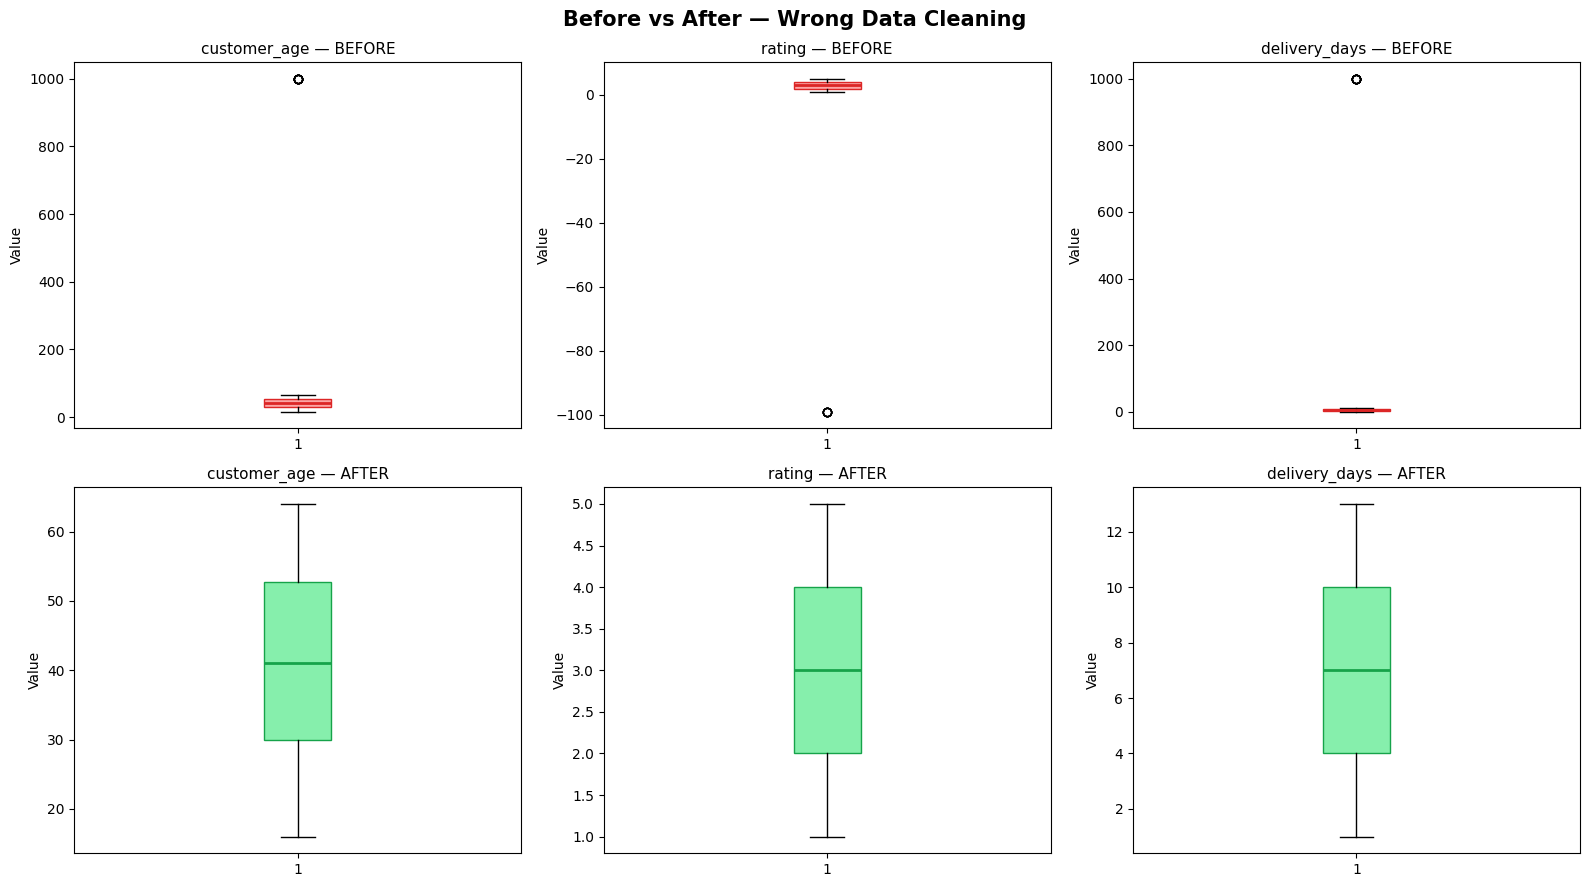

Comparison chart saved.


In [30]:
# ─────────────────────────────────────────────────────────────────
# CELL 4.7 — Before vs After: Wrong Data Comparison
# ─────────────────────────────────────────────────────────────────

# Visual comparison — box plots before and after for key numeric columns
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Before vs After — Wrong Data Cleaning', fontsize=15, fontweight='bold')

cols_compare = ['customer_age', 'rating', 'delivery_days']

for idx, col in enumerate(cols_compare):
    before_data = pd.to_numeric(df_raw[col], errors='coerce').dropna()
    after_data  = df_wd_clean[col].dropna()

    # Before
    axes[0, idx].boxplot(before_data, patch_artist=True,
                         boxprops=dict(facecolor='#fca5a5', color='#dc2626'),
                         medianprops=dict(color='#dc2626', linewidth=2))
    axes[0, idx].set_title(f'{col} — BEFORE', fontsize=11)
    axes[0, idx].set_ylabel('Value')

    # After
    axes[1, idx].boxplot(after_data, patch_artist=True,
                         boxprops=dict(facecolor='#86efac', color='#16a34a'),
                         medianprops=dict(color='#16a34a', linewidth=2))
    axes[1, idx].set_title(f'{col} — AFTER', fontsize=11)
    axes[1, idx].set_ylabel('Value')

plt.tight_layout()
plt.savefig('wrong_data_before_after.png', dpi=150, bbox_inches='tight')
plt.show()
print("Comparison chart saved.")

---
# SECTION 5: Removing Duplicates

---

## What Are Duplicate Rows?

A **duplicate row** is a row that appears more than once in a DataFrame with identical (or near-identical) values.

### Why Are Duplicates Dangerous?

| Impact | Consequence |
|---|---|
| Inflated totals | Revenue looks higher than it is |
| Wrong counts | Number of customers/orders appears too large |
| Skewed averages | Mean and median are pulled towards repeated values |
| Wrong rankings | Top products/regions ranked incorrectly |

### Types of Duplicates

| Type | Description |
|---|---|
| **Exact duplicates** | Every column is identical |
| **Key duplicates** | Same `order_id` but other columns differ (data entry error) |
| **Near-duplicates** | Same entity but slight differences (e.g., typo in name) |

---

## Key Functions

| Function | Purpose |
|---|---|
| `df.duplicated()` | Returns True/False Series — True = duplicate row |
| `df.duplicated(keep='first')` | Mark second+ occurrences as True (default) |
| `df.duplicated(keep='last')` | Mark all except last occurrence as True |
| `df.duplicated(keep=False)` | Mark ALL copies as True |
| `df.duplicated(subset=['col'])` | Check duplicates on specific columns only |
| `df.drop_duplicates()` | Remove duplicate rows |
| `df.drop_duplicates(subset=['col'])` | Remove rows with duplicate key column |

In [31]:
# ─────────────────────────────────────────────────────────────────
# CELL 5.1 — Detect Duplicates
# ─────────────────────────────────────────────────────────────────

df_dup = df.copy()

# Total duplicate rows (second and later occurrences)
total_dupes = df_dup.duplicated().sum()
print(f"Total duplicate rows (2nd+ occurrences): {total_dupes}")
print()

# Show the duplicate rows (keep=False marks EVERY copy — originals too)
all_dupe_rows = df_dup[df_dup.duplicated(keep=False)]
print(f"All rows involved in duplication (including originals): {len(all_dupe_rows)}")
print()
print("=== Sample duplicate rows ===")
print(all_dupe_rows[['order_id','customer_name','product_name','total_amount']].head(10))

Total duplicate rows (2nd+ occurrences): 30

All rows involved in duplication (including originals): 60

=== Sample duplicate rows ===
       order_id customer_name            product_name  total_amount
53   ORD-100053   Customer_45    Nigerian Law Reports      9,222.72
60   ORD-100060   Customer_45  Golden Penny Rice 25kg     13,140.10
97   ORD-100097   Customer_17    Nigerian Law Reports     19,703.19
132  ORD-100132   Customer_63        Samsung Smart TV    261,528.05
243  ORD-100243   Customer_28      LG Air Conditioner    704,559.04
261  ORD-100261   Customer_75         iPhone 15 128GB    869,324.90
272  ORD-100272   Customer_40      Maybelline Mascara     40,512.48
277  ORD-100277           NaN    Xiaomi Redmi Note 13    921,863.38
278  ORD-100278   Customer_93   Hisense Chest Freezer    879,746.26
306  ORD-100306   Customer_99     WAEC Past Questions     46,884.56


In [32]:
# ─────────────────────────────────────────────────────────────────
# CELL 5.2 — Understand keep= Options
# ─────────────────────────────────────────────────────────────────

# Demonstrate keep= parameter with a tiny example
demo = pd.DataFrame({
    'Name'  : ['Chidi', 'Amina', 'Tunde', 'Chidi', 'Amina', 'Ngozi'],
    'Amount': [5000,     12000,   8000,    5000,     12000,   7500   ]
})

print("=== Demo DataFrame ===")
print(demo)
print()

print("duplicated(keep='first') — mark 2nd+ occurrences:")
print(demo.duplicated(keep='first').tolist())

print()
print("duplicated(keep='last')  — mark all except LAST occurrence:")
print(demo.duplicated(keep='last').tolist())

print()
print("duplicated(keep=False)   — mark ALL copies:")
print(demo.duplicated(keep=False).tolist())

=== Demo DataFrame ===
    Name  Amount
0  Chidi    5000
1  Amina   12000
2  Tunde    8000
3  Chidi    5000
4  Amina   12000
5  Ngozi    7500

duplicated(keep='first') — mark 2nd+ occurrences:
[False, False, False, True, True, False]

duplicated(keep='last')  — mark all except LAST occurrence:
[True, True, False, False, False, False]

duplicated(keep=False)   — mark ALL copies:
[True, True, False, True, True, False]


In [33]:
# ─────────────────────────────────────────────────────────────────
# CELL 5.3 — Remove Exact Duplicates
# ─────────────────────────────────────────────────────────────────

df_dedup = df_dup.copy()

print(f"Rows BEFORE removing duplicates : {len(df_dedup)}")

# drop_duplicates() removes duplicate rows
# keep='first' — keep the FIRST occurrence, remove all subsequent copies (default)
df_dedup.drop_duplicates(keep='first', inplace=True)

# reset_index(drop=True) — renumber the row index 0,1,2,3... after gaps left by removed rows
df_dedup.reset_index(drop=True, inplace=True)

print(f"Rows AFTER  removing duplicates : {len(df_dedup)}")
print(f"Rows removed                    : {len(df_dup) - len(df_dedup)}")
print()
print(f"Remaining duplicates: {df_dedup.duplicated().sum()} (should be 0)")

Rows BEFORE removing duplicates : 630
Rows AFTER  removing duplicates : 600
Rows removed                    : 30

Remaining duplicates: 0 (should be 0)


In [34]:
# ─────────────────────────────────────────────────────────────────
# CELL 5.4 — Remove Duplicates Based on Key Column Only
# ─────────────────────────────────────────────────────────────────

# Sometimes two rows have the same order_id but other fields differ
# (e.g., one was updated). We want only ONE row per order_id.

# Simulate key-based duplicates
df_keyed = df_dedup.head(20).copy()
# Add a row with same order_id but different amount (data entry conflict)
extra = df_keyed.iloc[0:3].copy()
extra['total_amount'] = extra['total_amount'] * 1.1   # slightly different total
df_keyed = pd.concat([df_keyed, extra], ignore_index=True)

print(f"Rows before key-based dedup : {len(df_keyed)}")
print(f"Duplicate order_ids          : {df_keyed.duplicated(subset=['order_id']).sum()}")
print()

# Keep the LAST occurrence (most recent / most up-to-date)
df_keyed_dedup = df_keyed.drop_duplicates(subset=['order_id'], keep='last')
df_keyed_dedup.reset_index(drop=True, inplace=True)

print(f"Rows after key-based dedup  : {len(df_keyed_dedup)}")
print(f"Remaining duplicate order_ids: {df_keyed_dedup.duplicated(subset=['order_id']).sum()}")

Rows before key-based dedup : 23
Duplicate order_ids          : 3

Rows after key-based dedup  : 20
Remaining duplicate order_ids: 0


In [35]:
# ─────────────────────────────────────────────────────────────────
# CELL 5.5 — Duplicate Analysis: Which Rows Are Duplicated Most?
# ─────────────────────────────────────────────────────────────────

# Count how many times each order_id appears
order_counts = df_dup['order_id'].value_counts()
duplicated_orders = order_counts[order_counts > 1]

print(f"Order IDs appearing more than once: {len(duplicated_orders)}")
print()
print("=== Most duplicated orders ===")
print(duplicated_orders.head(10))
print()

# Show all copies of one specific duplicated order
if len(duplicated_orders) > 0:
    example_id = duplicated_orders.index[0]
    print(f"=== All copies of {example_id} ===")
    print(df_dup[df_dup['order_id'] == example_id][
        ['order_id','customer_name','product_name','total_amount','rating']
    ])

Order IDs appearing more than once: 30

=== Most duplicated orders ===
order_id
ORD-100097    2
ORD-100277    2
ORD-100261    2
ORD-100278    2
ORD-100272    2
ORD-100132    2
ORD-100060    2
ORD-100243    2
ORD-100053    2
ORD-100306    2
Name: count, dtype: int64

=== All copies of ORD-100097 ===
       order_id customer_name          product_name  total_amount  rating
97   ORD-100097   Customer_17  Nigerian Law Reports     19,703.19    3.00
624  ORD-100097   Customer_17  Nigerian Law Reports     19,703.19    3.00


In [36]:
# ─────────────────────────────────────────────────────────────────
# CELL 5.6 — Impact of Duplicates on Analysis (Before vs After)
# ─────────────────────────────────────────────────────────────────

# Show how duplicates distort analysis results

df_before = df_dup.copy()
df_before['total_amount'] = pd.to_numeric(df_before['total_amount'], errors='coerce')
df_before['rating']       = pd.to_numeric(df_before['rating'],       errors='coerce')

df_after = df_dedup.copy()
df_after['total_amount'] = pd.to_numeric(df_after['total_amount'], errors='coerce')
df_after['rating']       = pd.to_numeric(df_after['rating'],       errors='coerce')

print("=" * 55)
print(f"{'Metric':<30} {'WITH Dupes':>12} {'WITHOUT Dupes':>12}")
print("=" * 55)
print(f"{'Total rows':<30} {len(df_before):>12,} {len(df_after):>12,}")
print(f"{'Total revenue (sum)':<30} {df_before['total_amount'].sum():>12,.0f} {df_after['total_amount'].sum():>12,.0f}")
print(f"{'Avg order value (mean)':<30} {df_before['total_amount'].mean():>12,.0f} {df_after['total_amount'].mean():>12,.0f}")
print(f"{'Avg rating (mean)':<30} {df_before['rating'].mean():>12.3f} {df_after['rating'].mean():>12.3f}")
print(f"{'Unique customers':<30} {df_before['customer_name'].nunique():>12,} {df_after['customer_name'].nunique():>12,}")
print("=" * 55)
print()
rev_diff = df_before['total_amount'].sum() - df_after['total_amount'].sum()
print(f"Revenue OVERSTATEMENT due to duplicates: ₦{rev_diff:,.0f}")

Metric                           WITH Dupes WITHOUT Dupes
Total rows                              630          600
Total revenue (sum)             181,962,181  172,064,895
Avg order value (mean)              294,914      292,627
Avg rating (mean)                     2.049        1.979
Unique customers                        129          129

Revenue OVERSTATEMENT due to duplicates: ₦9,897,285


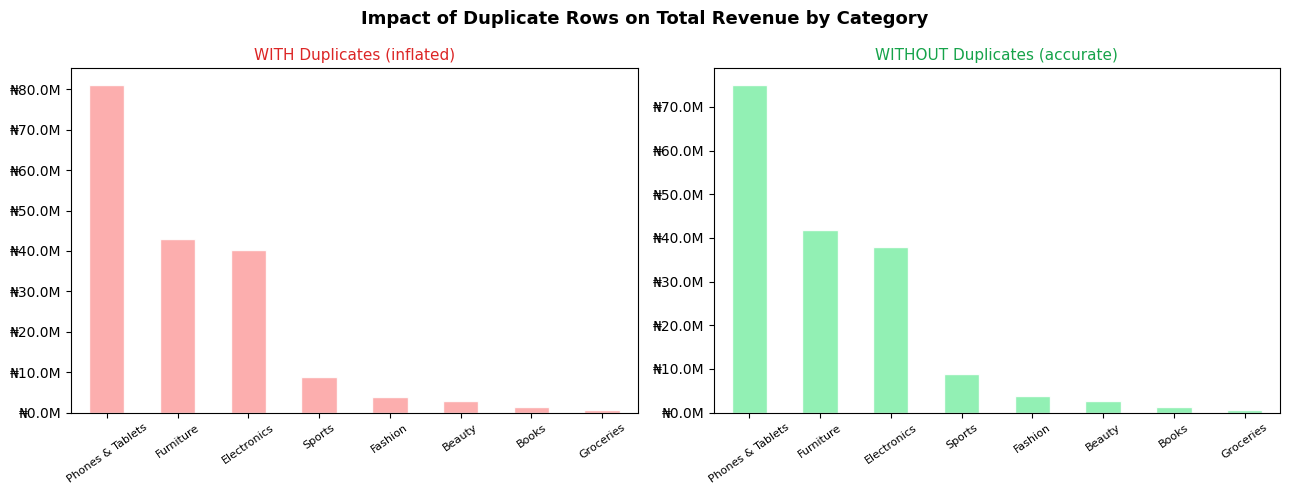

Chart saved.


In [37]:
# ─────────────────────────────────────────────────────────────────
# CELL 5.7 — Visual: Duplicates Distribution
# ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Impact of Duplicate Rows on Total Revenue by Category', fontsize=13, fontweight='bold')

# Before dedup
before_cat = df_before.groupby('category')['total_amount'].sum().sort_values(ascending=False)
before_cat.plot(kind='bar', ax=axes[0], color='#fca5a5', edgecolor='white', alpha=0.9)
axes[0].set_title('WITH Duplicates (inflated)', fontsize=11, color='#dc2626')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=35, labelsize=8)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₦{x/1e6:.1f}M'))

# After dedup
after_cat = df_after.groupby('category')['total_amount'].sum().sort_values(ascending=False)
after_cat.plot(kind='bar', ax=axes[1], color='#86efac', edgecolor='white', alpha=0.9)
axes[1].set_title('WITHOUT Duplicates (accurate)', fontsize=11, color='#16a34a')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=35, labelsize=8)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₦{x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig('duplicates_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

---
# SECTION 6: The Complete End-to-End Cleaning Pipeline

---

## Professional Data Cleaning Order

```
Step 1: LOAD        → read raw data, keep original untouched
Step 2: DEDUP       → remove duplicate rows first (less work to clean)
Step 3: CONVERT     → fix data types (especially dates and numbers)
Step 4: WRONG DATA  → replace impossible values with NaN
Step 5: EMPTY CELLS → fill or drop NaN values
Step 6: FORMAT      → standardise strings, phone, email, state
Step 7: ENRICH      → add derived/calculated columns
Step 8: VALIDATE    → confirm: 0 NaN, 0 duplicates, 0 outliers
Step 9: EXPORT      → save clean CSV and Excel
```

This section runs the full pipeline in one place — clean, commented, and production-ready.

In [38]:
# ═══════════════════════════════════════════════════════════════
# CELL 6.1 — STEP 1: LOAD RAW DATA
# ═══════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import re, warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('nigeria_cleaning_dataset.csv')   # load raw data — never modify this
print(f"[STEP 1] Loaded: {df.shape[0]} rows × {df.shape[1]} columns")

[STEP 1] Loaded: 630 rows × 20 columns


In [39]:
# ═══════════════════════════════════════════════════════════════
# CELL 6.2 — STEP 2: REMOVE DUPLICATES
# ═══════════════════════════════════════════════════════════════

dupes_before = df.duplicated().sum()
df.drop_duplicates(keep='first', inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"[STEP 2] Removed {dupes_before} duplicate rows | Rows now: {len(df)}")

[STEP 2] Removed 30 duplicate rows | Rows now: 600


In [40]:
# ═══════════════════════════════════════════════════════════════
# CELL 6.3 — STEP 3: CONVERT DATA TYPES
# ═══════════════════════════════════════════════════════════════

# Numeric columns
for col in ['unit_price','quantity','discount_pct','total_amount','customer_age','rating','delivery_days']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Date column — replace 'N/A' string first, then parse
df['order_date'] = df['order_date'].replace('N/A', np.nan)
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True, errors='coerce')

print(f"[STEP 3] Data types fixed")
print(df.dtypes[['unit_price','total_amount','customer_age','order_date']])

[STEP 3] Data types fixed
unit_price             float64
total_amount           float64
customer_age           float64
order_date      datetime64[ns]
dtype: object


In [41]:
# ═══════════════════════════════════════════════════════════════
# CELL 6.4 — STEP 4: REPLACE IMPOSSIBLE / WRONG VALUES WITH NaN
# ═══════════════════════════════════════════════════════════════

# customer_age: valid 1–100
df.loc[df['customer_age'] > 100, 'customer_age'] = np.nan
df.loc[df['customer_age'] < 1,   'customer_age'] = np.nan

# rating: valid 1–5
df.loc[df['rating'] < 1, 'rating'] = np.nan
df.loc[df['rating'] > 5, 'rating'] = np.nan

# delivery_days: valid 1–30
df.loc[df['delivery_days'] > 30, 'delivery_days'] = np.nan
df.loc[df['delivery_days'] < 1,  'delivery_days'] = np.nan

# total_amount: must be > 0
df.loc[df['total_amount'] <= 0, 'total_amount'] = np.nan

# unit_price: must be > 0
df.loc[df['unit_price'] <= 0, 'unit_price'] = np.nan

# state: invalid values → NaN
VALID_STATES = ['Lagos','Abuja','Kano','Rivers','Oyo','Delta','Kaduna','Enugu','Anambra','Imo']
df.loc[~df['state'].isin(VALID_STATES) & df['state'].notna(), 'state'] = np.nan

print(f"[STEP 4] Wrong values replaced with NaN")
print("Missing values now:")
print(df.isnull().sum()[df.isnull().sum() > 0])

[STEP 4] Wrong values replaced with NaN
Missing values now:
order_date        380
customer_name      30
customer_email     20
customer_phone     15
state              30
total_amount       25
customer_age       48
rating             41
delivery_days      18
dtype: int64


In [42]:
# ═══════════════════════════════════════════════════════════════
# CELL 6.5 — STEP 5: FILL EMPTY CELLS
# ═══════════════════════════════════════════════════════════════

# Numeric — fill with median (safe for skewed data)
df['customer_age'].fillna(df['customer_age'].median(),   inplace=True)
df['rating'].fillna(df['rating'].median(),               inplace=True)
df['delivery_days'].fillna(df['delivery_days'].median(), inplace=True)
df['total_amount'].fillna(df['total_amount'].median(),   inplace=True)
df['unit_price'].fillna(df['unit_price'].median(),       inplace=True)

# Dates — fill missing with mode (most common date)
df['order_date'].fillna(df['order_date'].mode()[0],      inplace=True)

# Categorical — fill with mode
df['state'].fillna(df['state'].mode()[0],                    inplace=True)
df['customer_segment'].fillna(df['customer_segment'].mode()[0], inplace=True)
df['payment_method'].fillna(df['payment_method'].mode()[0], inplace=True)

# Text — fill with placeholder constants
df['customer_name'].fillna('Unknown Customer',               inplace=True)
df['customer_email'].fillna('no-email@placeholder.ng',       inplace=True)
df['customer_phone'] = df['customer_phone'].astype(str).replace('nan', np.nan)
df['customer_phone'].fillna('0000000000', inplace=True)

print(f"[STEP 5] Empty cells filled")
print(f"Remaining NaN: {df.isnull().sum().sum()} (target = 0)")

[STEP 5] Empty cells filled
Remaining NaN: 0 (target = 0)


In [43]:
# ═══════════════════════════════════════════════════════════════
# CELL 6.6 — STEP 6: STANDARDISE STRING FORMAT
# ═══════════════════════════════════════════════════════════════

# Strip whitespace and title-case name fields
df['customer_name']    = df['customer_name'].str.strip().str.title()
df['state']            = df['state'].str.strip().str.title()
df['category']         = df['category'].str.strip().str.title()
df['product_name']     = df['product_name'].str.strip().str.title()
df['payment_method']   = df['payment_method'].str.strip().str.title()
df['customer_segment'] = df['customer_segment'].str.strip().str.title()
df['platform']         = df['platform'].str.strip().str.title()
df['customer_gender']  = df['customer_gender'].str.strip().str.title()
df['status'] = df.get('status', pd.Series(['Delivered']*len(df))).str.strip().str.title() if 'status' in df.columns else 'Delivered'

# Validate and clean phone numbers
def clean_phone(phone):
    if pd.isna(phone): return 'UNKNOWN'
    p = str(phone).strip()
    p = re.sub(r'[\s\-\(\)]', '', p)
    if p.startswith('+234'): p = '0' + p[4:]
    if len(p) == 10 and p[0] in ('7','8','9'): p = '0' + p
    return p if re.match(r'^0[7-9][0-1]\d{8}$', p) else 'INVALID'

df['customer_phone_clean'] = df['customer_phone'].apply(clean_phone)

print("[STEP 6] Strings standardised")
print(f"  Invalid phone numbers flagged: {(df['customer_phone_clean']=='INVALID').sum()}")

[STEP 6] Strings standardised
  Invalid phone numbers flagged: 600


In [44]:
# ═══════════════════════════════════════════════════════════════
# CELL 6.7 — STEP 7: ADD DERIVED / ENRICHMENT COLUMNS
# ═══════════════════════════════════════════════════════════════

# Recalculate total from components (more reliable after cleaning)
df['total_recalc']    = df['unit_price'] * df['quantity'] * (1 - df['discount_pct']/100)

# Date components
df['order_year']      = df['order_date'].dt.year
df['order_month']     = df['order_date'].dt.month
df['order_monthname'] = df['order_date'].dt.month_name()
df['order_quarter']   = 'Q' + df['order_date'].dt.quarter.astype(str)

# Customer age groups
df['age_group'] = pd.cut(
    df['customer_age'],
    bins=[0,17,25,35,45,55,65,110],
    labels=['Under 18','18-25','26-35','36-45','46-55','56-65','65+'],
    right=True
)

# High-value flag
df['is_high_value'] = df['total_amount'] > df['total_amount'].median()

# Discount tier
df['discount_tier'] = pd.cut(
    df['discount_pct'],
    bins=[-1,0,9,14,19,100],
    labels=['No Discount','0-9%','10-14%','15-19%','20%+'],
    right=True
)

print("[STEP 7] Derived columns added")
print(df[['order_date','order_quarter','age_group','discount_tier','is_high_value']].head(5))

[STEP 7] Derived columns added
  order_date order_quarter age_group discount_tier  is_high_value
0 2023-01-01            Q1     56-65        15-19%           True
1 2023-02-01            Q1     36-45          0-9%          False
2 2023-01-01            Q1     46-55   No Discount           True
3 2023-04-01            Q2     18-25        10-14%           True
4 2023-05-01            Q2     56-65          0-9%          False


In [45]:
# ═══════════════════════════════════════════════════════════════
# CELL 6.8 — STEP 8: VALIDATE — Final Quality Check
# ═══════════════════════════════════════════════════════════════

print("=" * 60)
print("FINAL VALIDATION REPORT")
print("=" * 60)
print(f"  Final shape      : {df.shape}")
print(f"  Duplicate rows   : {df.duplicated().sum()} (target: 0)")
print(f"  Missing values   : {df.isnull().sum().sum()} (target: 0)")
print()

# Numeric range checks
checks = [
    ('customer_age',   df['customer_age'].between(1, 100).all(),   "1–100"),
    ('rating',         df['rating'].between(1, 5).all(),           "1–5"),
    ('delivery_days',  df['delivery_days'].between(1, 30).all(),   "1–30"),
    ('total_amount',   (df['total_amount'] > 0).all(),             "> 0"),
]

print("  Range checks:")
for col, passed, expected_range in checks:
    status = "PASS" if passed else "FAIL"
    print(f"    {col:<20} {status}  (expected: {expected_range})")

print()
print("  State values — all valid?")
invalid_states_final = df[~df['state'].isin(VALID_STATES + ['Unknown Customer'])]
print(f"    Invalid states remaining: {len(invalid_states_final)}")

print()
print("=" * 60)
print("CLEAN DATASET READY FOR ANALYSIS")
print("=" * 60)

FINAL VALIDATION REPORT
  Final shape      : (600, 30)
  Duplicate rows   : 0 (target: 0)
  Missing values   : 0 (target: 0)

  Range checks:
    customer_age         PASS  (expected: 1–100)
    rating               PASS  (expected: 1–5)
    delivery_days        PASS  (expected: 1–30)
    total_amount         PASS  (expected: > 0)

  State values — all valid?
    Invalid states remaining: 0

CLEAN DATASET READY FOR ANALYSIS


In [46]:
# ═══════════════════════════════════════════════════════════════
# CELL 6.9 — STEP 9: EXPORT CLEAN DATA
# ═══════════════════════════════════════════════════════════════

# Save as CSV
clean_csv_path = 'nigeria_ecommerce_CLEAN.csv'
df.to_csv(clean_csv_path, index=False)
print(f"[STEP 9a] Saved clean CSV: {clean_csv_path}")

# Save as Excel (with openpyxl engine)
clean_xlsx_path = 'nigeria_ecommerce_CLEAN.xlsx'
df.to_excel(clean_xlsx_path, index=False, sheet_name='Clean_Data', engine='openpyxl')
print(f"[STEP 9b] Saved clean Excel: {clean_xlsx_path}")

# Verify saved files
import os
csv_size  = os.path.getsize(clean_csv_path)  / 1024
xlsx_size = os.path.getsize(clean_xlsx_path) / 1024
print(f"CSV size   : {csv_size:.1f} KB")

print(f"Excel size : {xlsx_size:.1f} KB")

[STEP 9a] Saved clean CSV: nigeria_ecommerce_CLEAN.csv
[STEP 9b] Saved clean Excel: nigeria_ecommerce_CLEAN.xlsx
CSV size   : 145.1 KB
Excel size : 99.9 KB


---
# SECTION 7: Post-Cleaning Analysis

---

Now that the data is clean, we can run accurate analysis.  
Every result here is based on verified, validated data — no duplicates, no wrong values, no missing data.

In [47]:
# ─────────────────────────────────────────────────────────────────
# CELL 7.1 — Revenue Analysis on Clean Data
# ─────────────────────────────────────────────────────────────────

print("=== Revenue by Category — Clean Data ===")
cat_rev = df.groupby('category').agg(
    Orders      = ('order_id',     'count'),
    Revenue     = ('total_amount', 'sum'  ),
    Avg_Order   = ('total_amount', 'mean' ),
    Avg_Rating  = ('rating',       'mean' )
).round(2).sort_values('Revenue', ascending=False)

print(cat_rev.to_string())

=== Revenue by Category — Clean Data ===
                  Orders       Revenue    Avg_Order  Avg_Rating
category                                                       
Phones & Tablets      75 75,255,877.51 1,003,411.70        3.12
Furniture             60 41,947,203.55   699,120.06        3.07
Electronics           82 38,166,454.90   465,444.57        3.15
Sports                74  8,996,965.80   121,580.62        3.08
Fashion               64  3,979,578.61    62,180.92        2.92
Beauty                86  2,782,881.89    32,359.09        2.87
Books                 87  1,633,298.84    18,773.55        3.24
Groceries             72    922,138.86    12,807.48        2.99


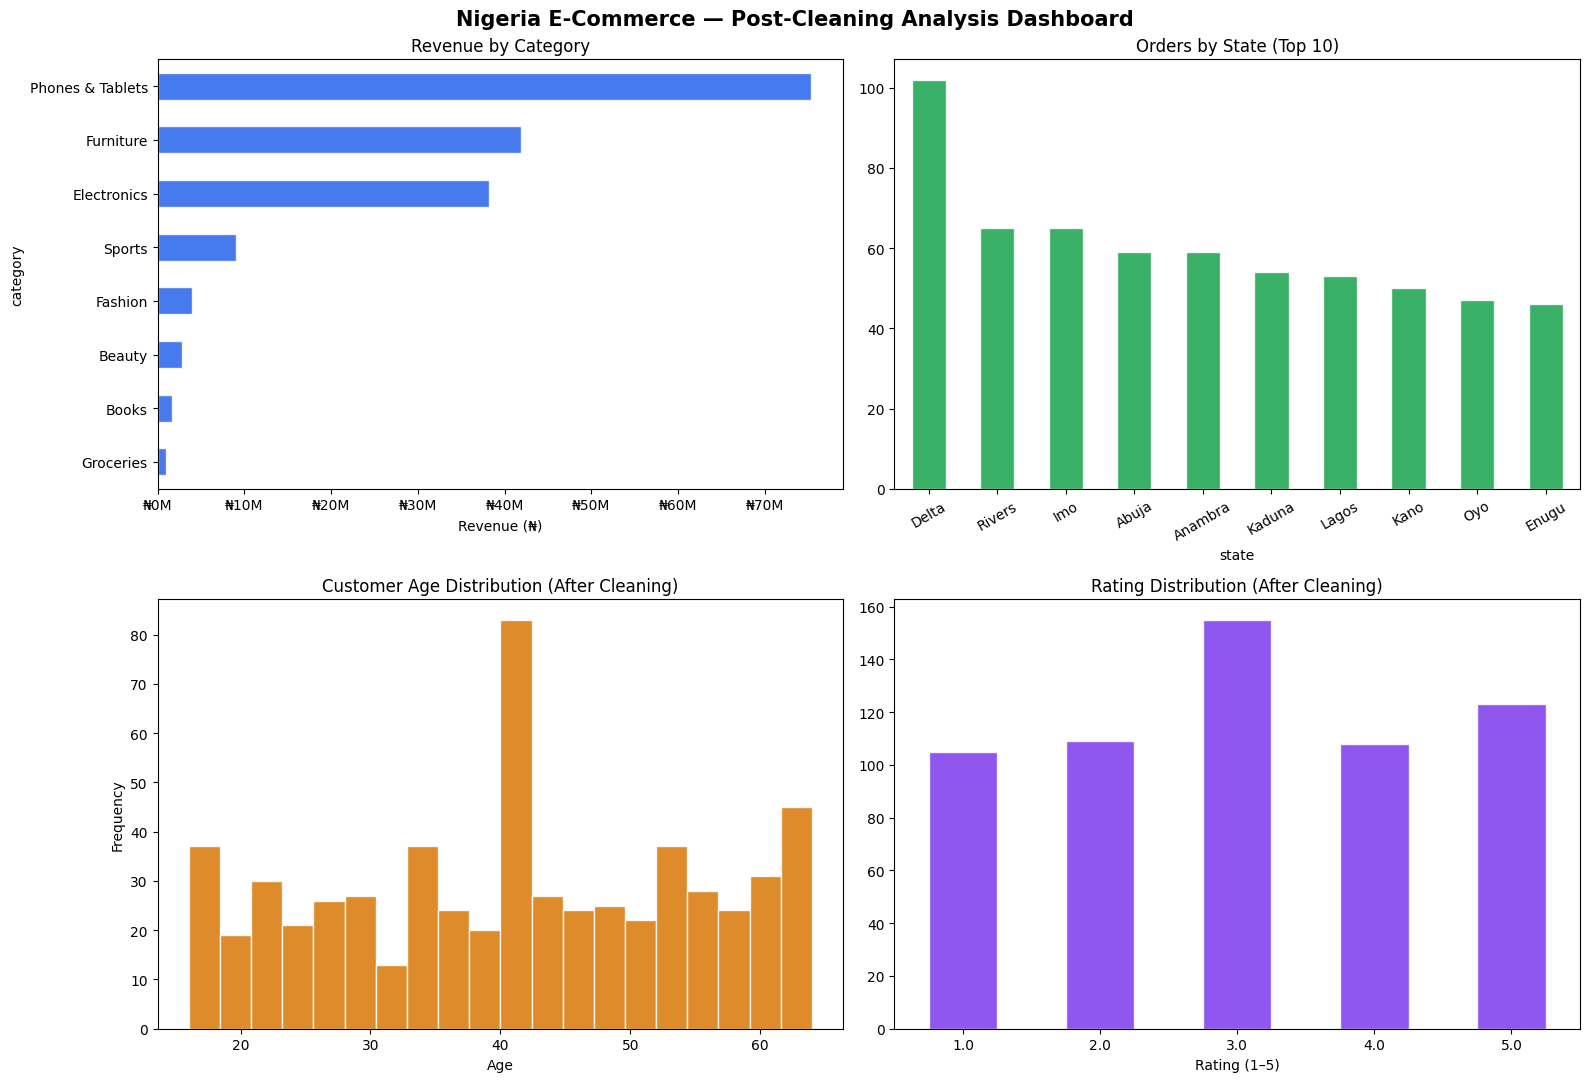

Dashboard saved.


In [48]:
# ─────────────────────────────────────────────────────────────────
# CELL 7.2 — Final Dashboard: 4 Charts
# ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Nigeria E-Commerce — Post-Cleaning Analysis Dashboard', fontsize=15, fontweight='bold')

# 1 — Revenue by Category
cat_rev_plot = df.groupby('category')['total_amount'].sum().sort_values(ascending=True)
cat_rev_plot.plot(kind='barh', ax=axes[0,0], color='#2563eb', alpha=0.85, edgecolor='white')
axes[0,0].set_title('Revenue by Category')
axes[0,0].set_xlabel('Revenue (₦)')
axes[0,0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₦{x/1e6:.0f}M'))

# 2 — Orders by State
state_cnt = df['state'].value_counts().head(10)
state_cnt.plot(kind='bar', ax=axes[0,1], color='#16a34a', alpha=0.85, edgecolor='white')
axes[0,1].set_title('Orders by State (Top 10)')
axes[0,1].tick_params(axis='x', rotation=30)

# 3 — Customer Age Distribution
df['customer_age'].plot(kind='hist', bins=20, ax=axes[1,0],
                        color='#d97706', alpha=0.85, edgecolor='white')
axes[1,0].set_title('Customer Age Distribution (After Cleaning)')
axes[1,0].set_xlabel('Age')

# 4 — Rating Distribution
df['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1,1], color='#7c3aed', alpha=0.85, edgecolor='white')
axes[1,1].set_title('Rating Distribution (After Cleaning)')
axes[1,1].set_xlabel('Rating (1–5)')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('post_cleaning_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved.")

---
# SECTION 8: Applying Cleaning to the Excel File

---

The Excel file `nigeria_cleaning_dataset.xlsx` has **4 sheets**, each focused on a specific cleaning topic:

| Sheet | Focus |
|---|---|
| `Sales_Dirty` | All dirt types combined |
| `Duplicates_Demo` | Duplicate rows |
| `WrongFormat_Demo` | Wrong format (dates, phones, emails) |
| `EmptyCells_Demo` | Empty cells |

In [49]:
# ─────────────────────────────────────────────────────────────────
# CELL 8.1 — Load and Clean the EmptyCells_Demo Sheet
# ─────────────────────────────────────────────────────────────────

df_empty = pd.read_excel(
    'nigeria_cleaning_dataset.xlsx',
    sheet_name='EmptyCells_Demo',
    na_values=['N/A','missing','--','none','Unknown']
)

print("=== EmptyCells_Demo — before cleaning ===")
print(f"Shape: {df_empty.shape}")
print(df_empty.isnull().sum()[df_empty.isnull().sum() > 0])
print()

# Clean
for col in ['customer_age','rating','total_amount','delivery_days']:
    df_empty[col] = pd.to_numeric(df_empty[col], errors='coerce')

df_empty.loc[df_empty['customer_age'] > 100, 'customer_age'] = np.nan
df_empty.loc[df_empty['rating'] < 1, 'rating'] = np.nan
df_empty.loc[df_empty['rating'] > 5, 'rating'] = np.nan
df_empty.loc[df_empty['total_amount'] <= 0, 'total_amount'] = np.nan
df_empty.loc[df_empty['delivery_days'] > 30, 'delivery_days'] = np.nan

for col in ['customer_age','rating','total_amount','delivery_days']:
    df_empty[col].fillna(df_empty[col].median(), inplace=True)

df_empty['customer_name'].fillna('Unknown Customer', inplace=True)
df_empty['customer_email'].fillna('no-email@placeholder.ng', inplace=True)
df_empty['customer_phone'] = df_empty['customer_phone'].astype(object)
df_empty['customer_phone'].fillna('0000000000', inplace=True)
df_empty['state'].fillna(df_empty['state'].mode()[0], inplace=True)

print("=== After cleaning ===")
print(f"Missing values remaining: {df_empty.isnull().sum().sum()}")

=== EmptyCells_Demo — before cleaning ===
Shape: (200, 9)
customer_name     13
customer_email     8
customer_phone     6
state              4
customer_age      12
rating             9
total_amount       5
delivery_days      2
dtype: int64

=== After cleaning ===
Missing values remaining: 0


In [50]:
# ─────────────────────────────────────────────────────────────────
# CELL 8.2 — Load and Clean the Duplicates_Demo Sheet
# ─────────────────────────────────────────────────────────────────

df_dup_xl = pd.read_excel(
    'nigeria_cleaning_dataset.xlsx',
    sheet_name='Duplicates_Demo'
)

print("=== Duplicates_Demo — before ===")
print(f"Rows: {len(df_dup_xl)}  |  Duplicates: {df_dup_xl.duplicated().sum()}")
print()

df_dup_xl.drop_duplicates(keep='first', inplace=True)
df_dup_xl.reset_index(drop=True, inplace=True)

print("=== After removing duplicates ===")
print(f"Rows: {len(df_dup_xl)}  |  Duplicates: {df_dup_xl.duplicated().sum()}")

=== Duplicates_Demo — before ===
Rows: 175  |  Duplicates: 25

=== After removing duplicates ===
Rows: 150  |  Duplicates: 0


In [51]:
# ─────────────────────────────────────────────────────────────────
# CELL 8.3 — Load and Clean the WrongFormat_Demo Sheet
# ─────────────────────────────────────────────────────────────────

df_fmt_xl = pd.read_excel(
    'nigeria_cleaning_dataset.xlsx',
    sheet_name='WrongFormat_Demo',
    na_values=['N/A','missing','--']
)

print("=== WrongFormat_Demo — dtypes before ===")
print(df_fmt_xl.dtypes)
print()

# Fix order_date
df_fmt_xl['order_date'] = df_fmt_xl['order_date'].replace('N/A', np.nan)
df_fmt_xl['order_date'] = pd.to_datetime(df_fmt_xl['order_date'], dayfirst=True, errors='coerce')

# Fix numeric columns
for col in ['customer_age','rating','delivery_days']:
    df_fmt_xl[col] = pd.to_numeric(df_fmt_xl[col], errors='coerce')

print("=== Dtypes after fixing ===")
print(df_fmt_xl.dtypes)
print()
print("Sample order_dates after fix:")
print(df_fmt_xl['order_date'].head(6))

=== WrongFormat_Demo — dtypes before ===
order_id           object
order_date         object
customer_name      object
customer_phone    float64
customer_email     object
customer_age      float64
rating            float64
delivery_days     float64
dtype: object

=== Dtypes after fixing ===
order_id                  object
order_date        datetime64[ns]
customer_name             object
customer_phone           float64
customer_email            object
customer_age             float64
rating                   float64
delivery_days            float64
dtype: object

Sample order_dates after fix:
0   2023-01-01
1   2023-02-01
2          NaT
3   2023-04-01
4   2023-05-01
5   2023-07-01
Name: order_date, dtype: datetime64[ns]


---
# SECTION 9: Complete Data Cleaning Cheat Sheet

---

## Detecting Problems

```python
df.info()                              # column types + non-null count
df.isnull().sum()                      # missing values per column
df.isnull().sum().sum()                # total missing cells
df.duplicated().sum()                  # total duplicate rows
df.describe()                          # statistical summary — spot bad min/max
df['col'].value_counts(dropna=False)   # frequency of each value (including NaN)
df['col'].unique()                     # all unique values
df[df['col'].isnull()]                 # rows where a column is missing
```

---

## Cleaning Empty Cells

```python
df.dropna()                            # remove rows with ANY missing value
df.dropna(subset=['col'])              # remove rows only where col is NaN
df.dropna(how='all')                   # remove rows where ALL values are NaN
df.dropna(thresh=n)                    # keep rows with at least n non-null values

df['col'].fillna(value)                # fill NaN with a constant
df['col'].fillna(df['col'].mean())     # fill with mean
df['col'].fillna(df['col'].median())   # fill with median (better when outliers exist)
df['col'].fillna(df['col'].mode()[0])  # fill with mode (best for text/categorical)
df['col'].ffill()                      # forward fill
df['col'].bfill()                      # backward fill
```

---

## Cleaning Wrong Format

```python
pd.to_datetime(df['col'], dayfirst=True, errors='coerce')  # fix date format
pd.to_numeric(df['col'], errors='coerce')                  # fix numeric format
df['col'].str.strip()                  # remove whitespace
df['col'].str.title()                  # 'north' → 'North'
df['col'].str.lower()                  # all lowercase
df['col'].str.upper()                  # ALL UPPERCASE
df['col'].str.replace('old','new')     # replace substring
re.match(pattern, value)               # validate with regex

# Date components (after pd.to_datetime)
df['col'].dt.year
df['col'].dt.month_name()
df['col'].dt.day_name()
df['col'].dt.quarter
```

---

## Cleaning Wrong Data

```python
# Replace impossible values with NaN
df.loc[df['age'] > 120, 'age'] = np.nan
df.loc[df['rating'] < 1, 'rating'] = np.nan
df.loc[df['price'] < 0, 'price'] = np.nan

# Then fill NaN with median or mode
df['age'].fillna(df['age'].median(), inplace=True)

# Conditional column
df['flag'] = np.where(condition, 'bad', 'ok')

# Bin into valid ranges
pd.cut(df['col'], bins=[...], labels=[...])
```

---

## Removing Duplicates

```python
df.duplicated().sum()                            # count duplicates
df[df.duplicated(keep=False)]                    # view all duplicate rows
df.drop_duplicates(keep='first')                 # remove duplicates, keep first
df.drop_duplicates(keep='last')                  # keep last
df.drop_duplicates(subset=['order_id'])          # dedup on specific key
df.reset_index(drop=True, inplace=True)          # renumber index after removal
```

---

## Professional Cleaning Order

```
1. Remove duplicates    (drop_duplicates)
2. Fix data types       (to_numeric, to_datetime)
3. Fix wrong data       (loc conditions → NaN)
4. Fill empty cells     (fillna with median/mode/constant)
5. Fix formats          (str.strip, str.title, regex)
6. Add derived columns  (feature engineering)
7. Validate             (isnull().sum(), duplicated().sum(), describe())
8. Export               (to_csv, to_excel)
```

---

> *"Cleaning data is not a chore — it is the most important act of respect you can show your analysis."*  
> — **Prodigy Training Hub**

---